# Vizualizacije za ICRA26

In [1]:
import os
import csv
import yaml
import copy
import numpy as np
import pandas as pd
from bagpy import bagreader
import matplotlib.pyplot as plt

import scienceplots
plt.style.use(['science', 'ieee'])
# --- paths ---
csv_path = "./data/masa-radijus.csv"        # update if needed
save_dir = "figures"         # change or keep "."
os.makedirs(save_dir, exist_ok=True)

### Masa - radijus
Usporedba mase s radijusom za okrugle i kvadraticaste oblike. 

15cm je radijus koji maks moze aktivirati gripper tako da iznad toga nismo testirali. 

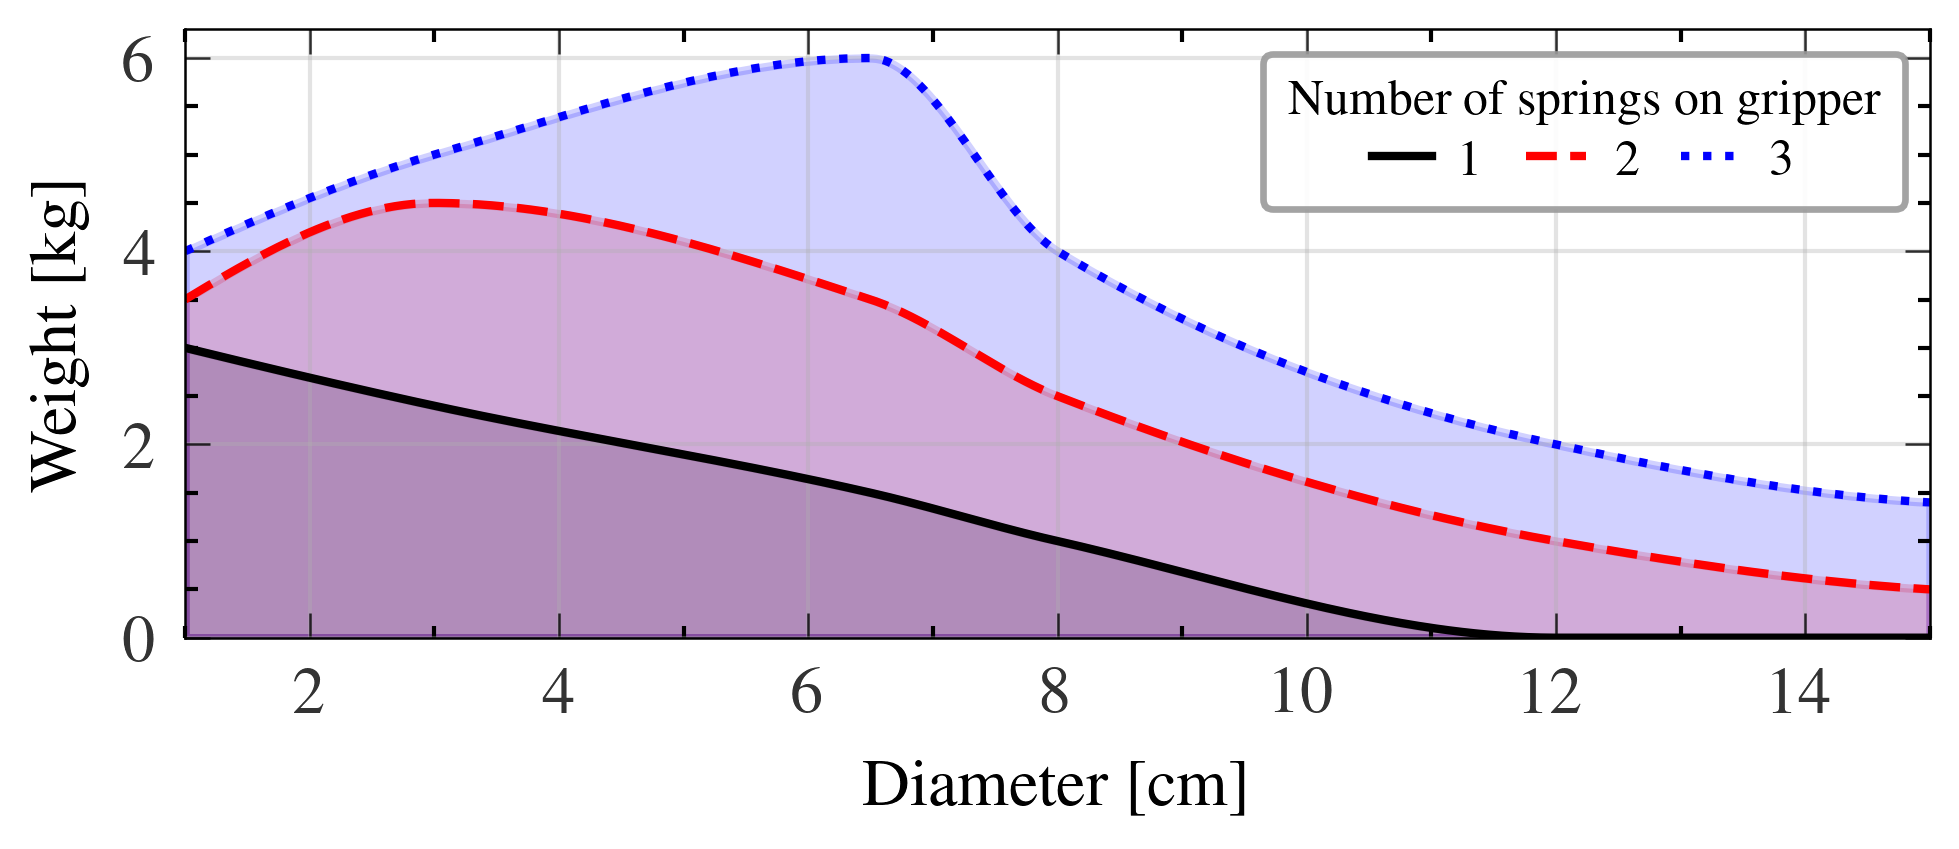

Saved: figures/round.pdf


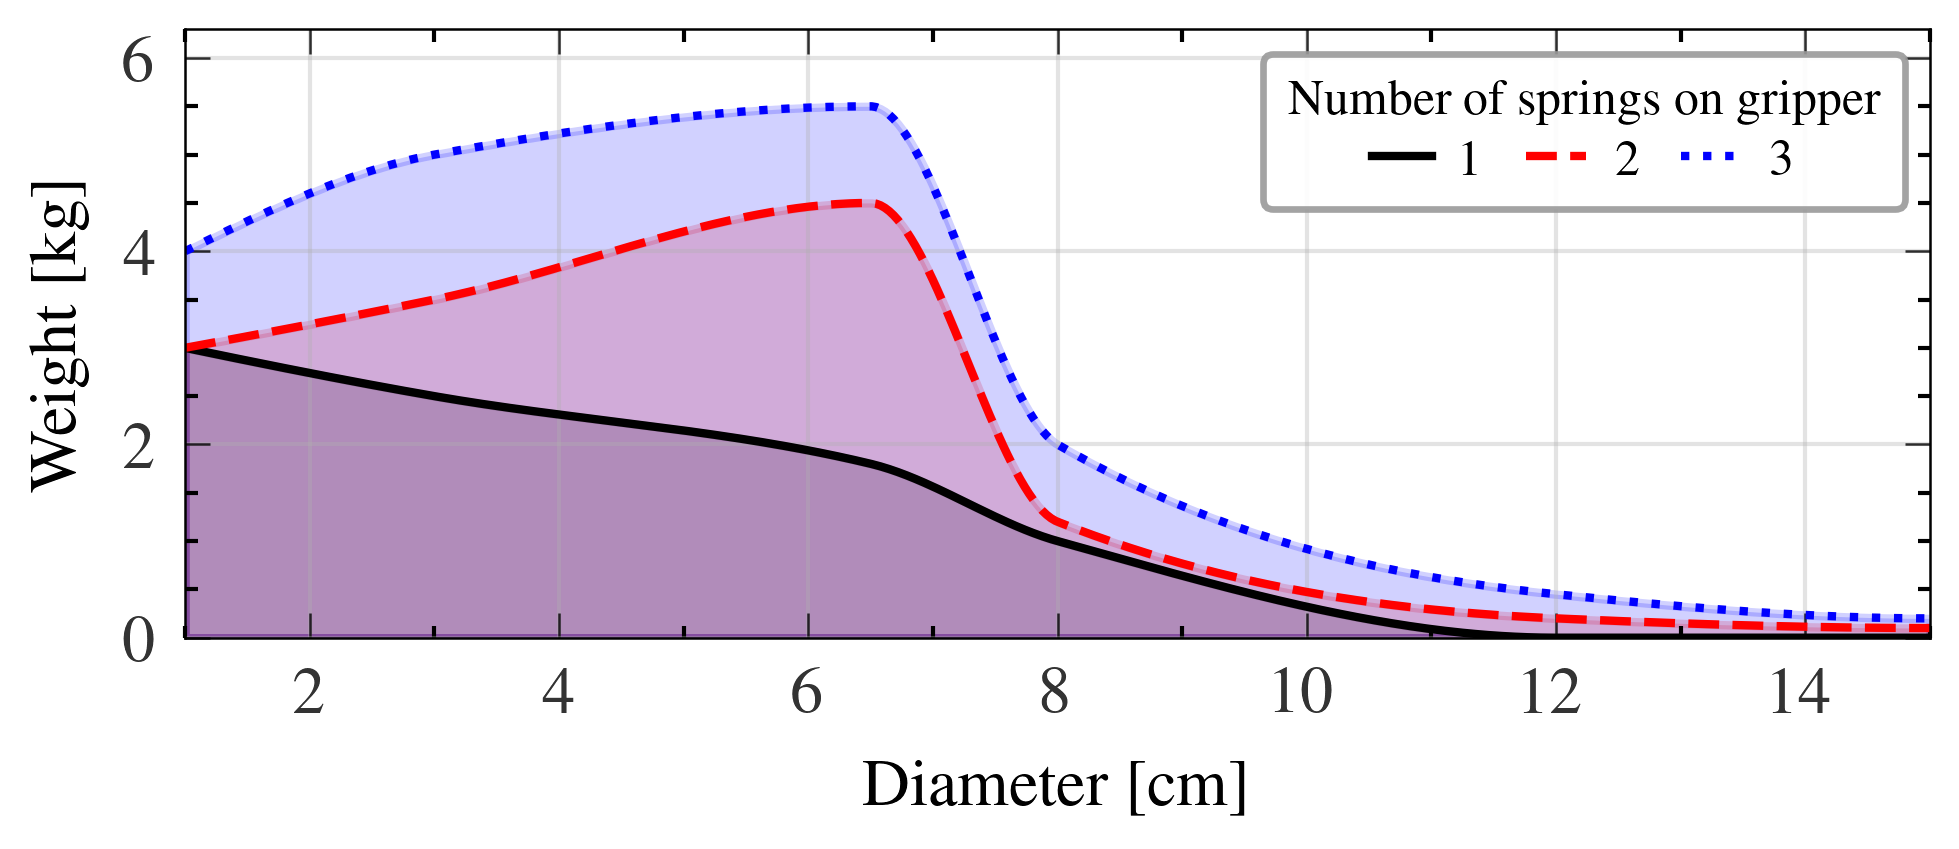

Saved: figures/squared.pdf


In [ ]:


# --- load (no renaming) ---
df = pd.read_csv(csv_path, encoding="utf-8-sig")
# ensure numeric types
df["number of springs"] = pd.to_numeric(df["number of springs"], errors="coerce")
df["radius"]            = pd.to_numeric(df["radius"], errors="coerce")
df["max weight"]        = pd.to_numeric(df["max weight"], errors="coerce")
df = df.dropna(subset=["number of springs", "shape", "radius", "max weight"])

# interpolation (PCHIP if available, else linear)
try:
    from scipy.interpolate import PchipInterpolator
    def interp_dense(xs, ys, xq):
        return PchipInterpolator(xs, ys)(xq)
except Exception:
    def interp_dense(xs, ys, xq):
        return np.interp(xq, xs, ys)

# common x ticks
x_ticks = sorted(df["radius"].unique())

# IEEE column-sized figures
FIGSIZE_IN = (3.25, 1.4)
DPI = 600
N_SAMPLES = 400

def plot_shape(shape_value: str):
    sub = df[df["shape"] == shape_value].copy()
    if sub.empty:
        return
    fig, ax = plt.subplots(figsize=FIGSIZE_IN, constrained_layout=True)

    ymax = 0.0
    for n_springs, g in sub.groupby("number of springs"):
        g = g.sort_values("radius")
        xs = g["radius"].to_numpy()
        ys = g["max weight"].to_numpy()

        xq = np.linspace(xs.min(), xs.max(), N_SAMPLES)
        yq = interp_dense(xs, ys, xq)

        (line,) = ax.plot(xq, yq, label=f"{int(n_springs)}")
        # ax.scatter(xs, ys, s=14)
        ax.fill_between(xq, yq, alpha=0.18, color=line.get_color())
        ymax = max(ymax, float(np.nanmax(yq)))

    from matplotlib.ticker import MultipleLocator, AutoMinorLocator

    ax.set_xlabel("Diameter [cm]")
    ax.set_ylabel("Weight [kg]")
    ax.set_xticks(x_ticks)
    ax.set_ylim(0, 6.3) #ymax * 1.08 if ymax > 0 else 1)
    ax.grid(True, alpha=0.35)
    x_min, x_max = sub["radius"].min(), sub["radius"].max()
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(MultipleLocator(2.0))   # 1 cm between ticks
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    lgd = ax.legend(title="Number of springs", fontsize=8, frameon=False)
    if lgd and lgd.get_title():
        lgd.get_title().set_fontsize(8)
    lgd = ax.legend(
    title="Number of springs on gripper",
    title_fontsize=6,
    fontsize=6,
    loc="upper right",          # try "lower left" if it overlaps
    ncol=3,                     # or 3 to make a single-row legend
    frameon=True,               # draw box
    fancybox=True,              # rounded corners
    framealpha=0.9,             # box opacity
    facecolor="white",          # box fill
    edgecolor="0.6",            # border color
    borderpad=0.5,              # padding inside box
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
    ax.tick_params(colors=(0, 0, 0, 0.8), width=0.3)
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
    out_path = os.path.join(save_dir, f"{shape_value}.pdf")  # filename uses CSV value
    plt.show()
    fig.savefig(out_path, format="pdf", dpi=DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

for shape_val in df["shape"].unique():
    plot_shape(shape_val)


### Otvaranje grippera
Graf otvaranja grippera s označenim područjima otvaranja, detekcije otvorenog i otpuštanja. Nacrtati uav/yaw i referencu kutne brzine. Moze se i pokazati stvarna kutna brzina da se prestane dogadati u jednom trenu.

In [2]:
# b  = bagreader('/home/jakob/Desktop/icra26/bags/dva_dobra_za_redom.bag')
b  = bagreader('/home/jakob/Desktop/icra26/bags/2025-09-11-20-20-48.bag')

uav_yaw =  pd.read_csv(b.message_by_topic('/red/uav/yaw'))
ang_ref = pd.read_csv(b.message_by_topic('/red/carrot/setpoint'))
ang_meas = pd.read_csv(b.message_by_topic('/red/vrpn_client/estimated_odometry'))

# Align time bases
t0_yaw = uav_yaw.iloc[[0]].values[0][0]
t0_ang = ang_ref.iloc[[0]].values[0][0]

delta_time = t0_yaw - t0_ang
print(f"Time shift: {delta_time:.3f} s")

uav_yaw['Time'] = uav_yaw['Time'] - t0_yaw

ang_ref = ang_ref[ang_ref['Time'] >= t0_yaw].copy()
ang_ref['Time'] -= t0_yaw

ang_meas = ang_meas[ang_meas['Time'] >= t0_yaw].copy()
ang_meas['Time'] -= t0_yaw

[INFO]  Data folder /home/jakob/Desktop/icra26/bags/2025-09-11-20-20-48 already exists. Not creating.
Time shift: 0.059 s


In [7]:
t0 = 63
t1 = 100
def window(T, Y, t0=5, t1=15):
    import numpy as np
    T = np.asarray(T); Y = np.asarray(Y)
    m = (T >= t0) & (T <= t1)
    return T[m], Y[m]

# Slice to [5, 15]
t_yaw, y_yaw   = window(uav_yaw['Time'],  uav_yaw['data'],  t0, t1)
t_ref, y_ref   = window(ang_ref['Time'],  ang_ref['velocity.angular.z'],  t0, t1)
t_meas, y_meas = window(ang_meas['Time'], ang_meas['twist.twist.angular.z'], t0, t1)

# PlotŽ
import matplotlib.pyplot as plt
FIGSIZE_IN = (3.25, 2.2); DPI = 600
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_IN, constrained_layout=True, sharex=True)

ax1.plot(t_yaw, y_yaw, color='tab:blue')
ax1.set_ylabel('Yaw [rad]'); ax1.grid(True, alpha=0.35)

ax2.plot(t_ref,  y_ref,  label='Reference', color='tab:red')
ax2.plot(t_meas, y_meas, '--', label='Measurement', color='tab:green')
ax2.set_xlabel('Time [s]'); ax2.set_ylabel(r'$\omega_z$ [rad/s]'); ax2.grid(True, alpha=0.5)
ax2.legend(frameon=True, fancybox=True, framealpha=0.9, edgecolor='0.3', fontsize=8)

# after plotting the lines, before plt.show() / savefig
for ax in (ax1, ax2):
    ax.axvspan(65, 77.5, facecolor='blue', alpha=0.16, edgecolor='none', zorder=0)
    ax.axvspan(77.5, 80.5, facecolor='red', alpha=0.16, edgecolor='none', zorder=0)
    ax.axvspan(80.5, 96.5, facecolor='green', alpha=0.16, edgecolor='none', zorder=0)

lgd = ax2.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax2.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper right",          # try "lower left" if it overlaps
    ncol=1,                     # or 3 to make a single-row legend
    frameon=True,               # draw box
    fancybox=True,              # rounded corners
    framealpha=0.6,             # box opacity
    facecolor="white",          # box fill
    edgecolor="0.6",            # border color
    borderpad=0.2,              # padding inside box
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)

# Save or show
out_path = os.path.join(save_dir, 'open_and_release_gripper.png')  # filename uses CSV value
fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
plt.show()

/tmp/ipykernel_28470/3778277961.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


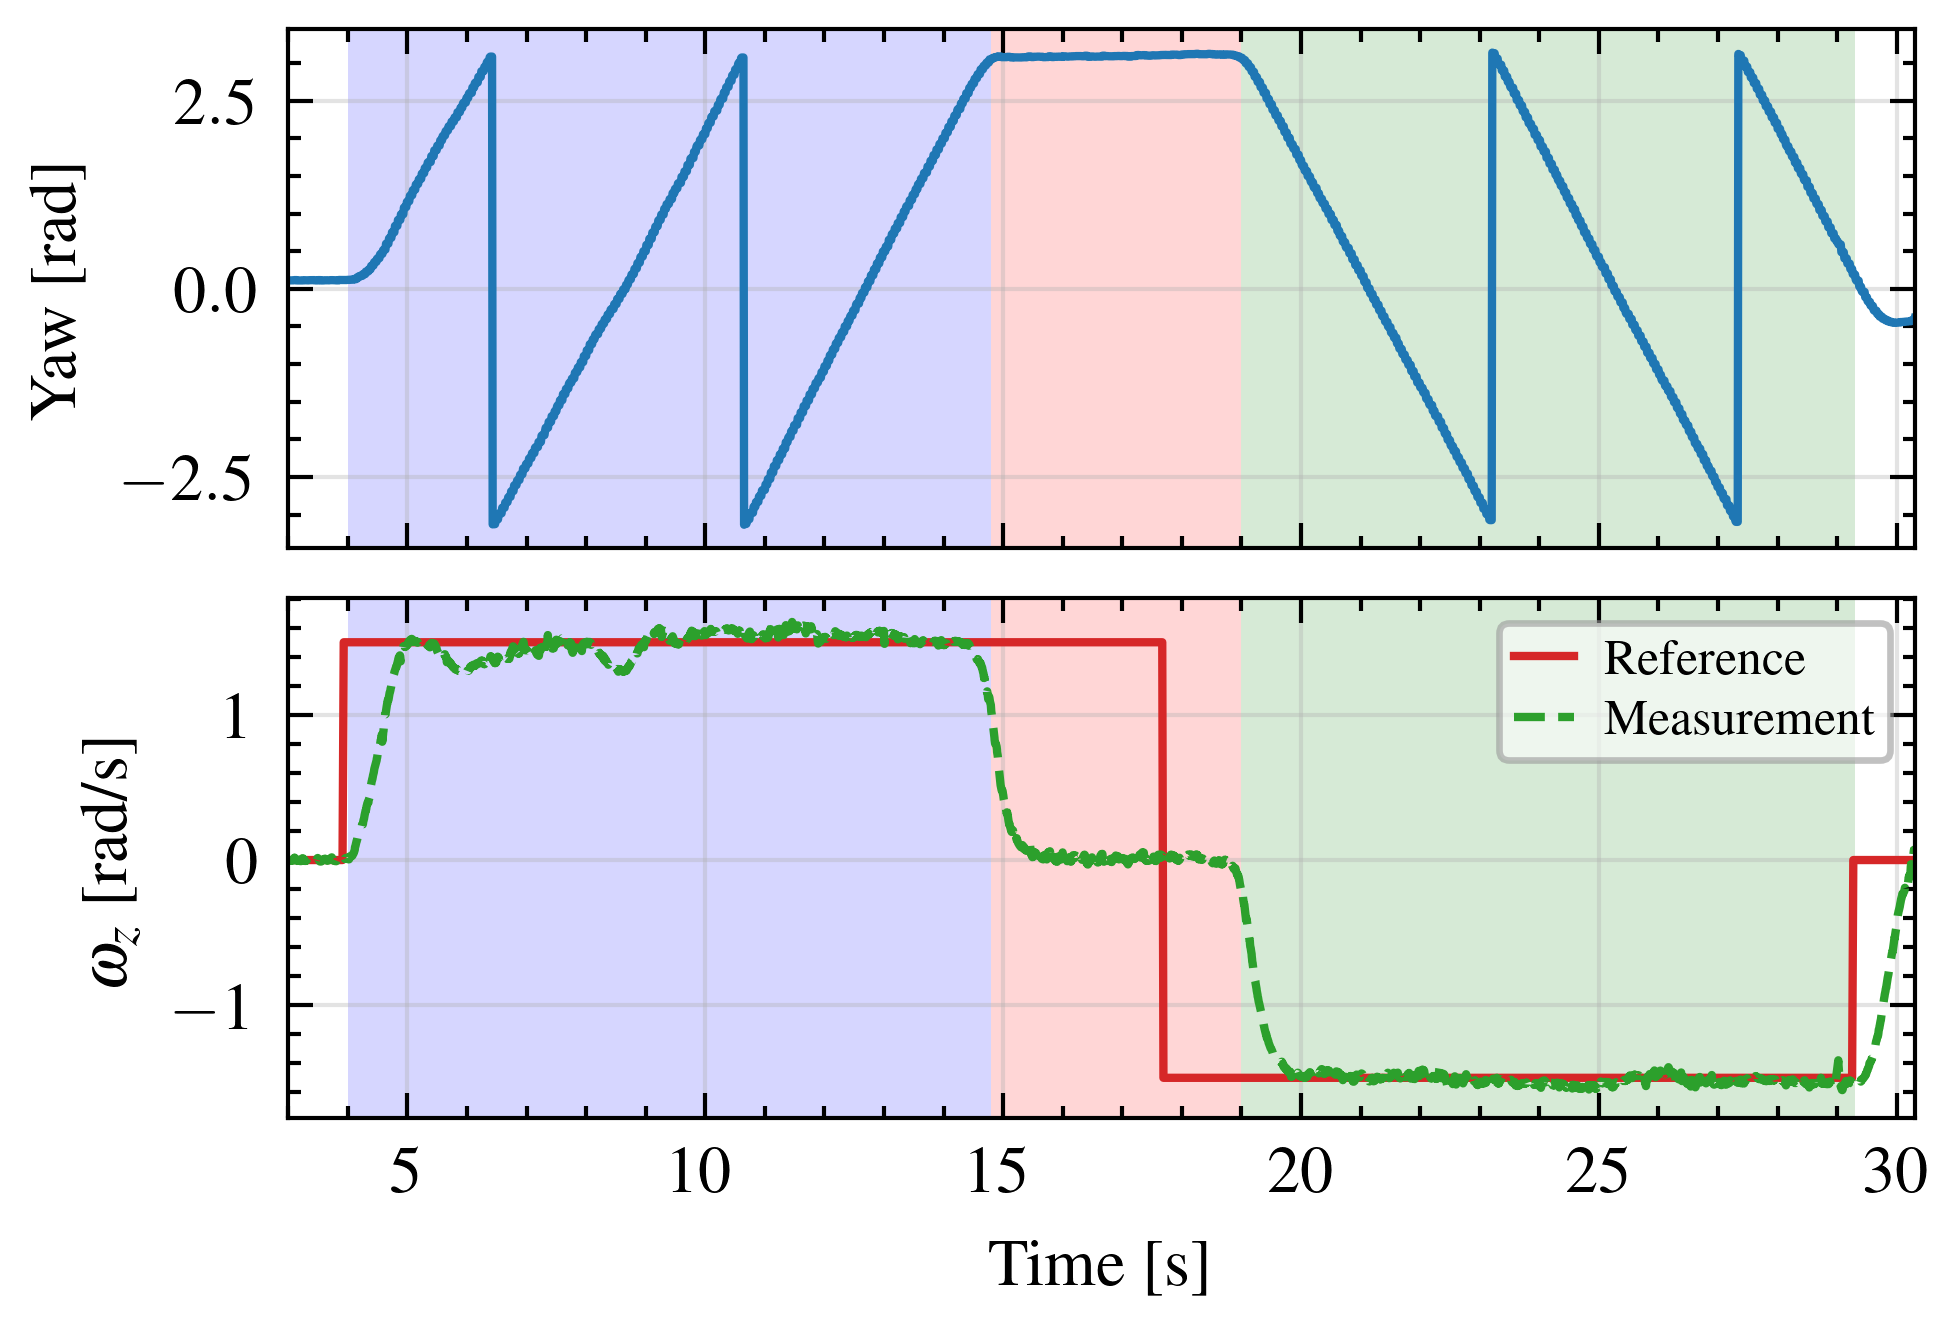

In [3]:
# --- choose window and axis start ---
t0 = 17.5
t1 = 44.8
AXIS_START = 3.0  # x-axis will start at 3 s

def window(T, Y, t0=5, t1=15):
    import numpy as np
    T = np.asarray(T); Y = np.asarray(Y)
    m = (T >= t0) & (T <= t1)
    return T[m], Y[m]

# Slice absolute times
t_yaw,  y_yaw  = window(uav_yaw['Time'],  uav_yaw['data'],                    t0, t1)
t_ref,  y_ref  = window(ang_ref['Time'],  ang_ref['velocity.angular.z'],      t0, t1)
t_meas, y_meas = window(ang_meas['Time'], ang_meas['twist.twist.angular.z'],  t0, t1)

# --- rebase to relative axis starting at 3 s ---
def rebase(t_abs, base=t0, offset=AXIS_START):
    return (t_abs - base) + offset

t_yaw_r  = rebase(t_yaw)
t_ref_r  = rebase(t_ref)
t_meas_r = rebase(t_meas)

# helper to shift spans
def span(a, b, base=t0, offset=AXIS_START):
    return (a - base) + offset, (b - base) + offset

s1a, s1b = span(18.5,29.3)    # blue
s2a, s2b = span(29.3,33.5)  # red
s3a, s3b = span(33.5,43.8)  # green

# --- plot (unchanged except using *_r and shifted spans) ---
import matplotlib.pyplot as plt
FIGSIZE_IN = (3.25, 2.2); DPI = 600
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_IN, constrained_layout=True, sharex=True)

ax1.plot(t_yaw_r, y_yaw, color='tab:blue')
ax1.set_ylabel('Yaw [rad]'); ax1.grid(True, alpha=0.35)

ax2.plot(t_ref_r,  y_ref,  label='Reference',   color='tab:red')
ax2.plot(t_meas_r, y_meas, '--', label='Measurement', color='tab:green')
ax2.set_xlabel('Time [s]'); ax2.set_ylabel(r'$\omega_z$ [rad/s]'); ax2.grid(True, alpha=0.35)

# spans in rebased coordinates
for ax in (ax1, ax2):
    ax.axvspan(s1a, s1b, facecolor='blue',  alpha=0.16, edgecolor='none', zorder=0)
    ax.axvspan(s2a, s2b, facecolor='red',   alpha=0.16, edgecolor='none', zorder=0)
    ax.axvspan(s3a, s3b, facecolor='green', alpha=0.16, edgecolor='none', zorder=0)

# optional: lock x-limits exactly to [3, 3 + (t1 - t0)]
ax2.set_xlim(AXIS_START, AXIS_START + (t1 - t0))

ax2.legend(loc='best', frameon=True, fancybox=True, framealpha=0.9, edgecolor='0.3', fontsize=8)
lgd = ax2.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax2.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper right",          # try "lower left" if it overlaps
    ncol=1,                     # or 3 to make a single-row legend
    frameon=True,               # draw box
    fancybox=True,              # rounded corners
    framealpha=0.6,             # box opacity
    facecolor="white",          # box fill
    edgecolor="0.6",            # border color
    borderpad=0.3,              # padding inside box
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)
# Save/show
fig.savefig(os.path.join(save_dir, 'open_and_release_gripper_v2.png'), dpi=DPI, bbox_inches="tight")
plt.show()


# Trajektorija

In [60]:
bag_name_1 = 'dva_puta_dobro.bag'
bag_name_2 = 'dobro_1_puta_19_47_39.bag'
b1  = bagreader('/home/jakob/Desktop/icra26/bags/full_test/' + bag_name_1)
b2  = bagreader('/home/jakob/Desktop/icra26/bags/full_test/' + bag_name_2)

[INFO]  Data folder /home/jakob/Desktop/icra26/bags/full_test/dva_puta_dobro already exists. Not creating.
[INFO]  Data folder /home/jakob/Desktop/icra26/bags/full_test/dobro_1_puta_19_47_39 already exists. Not creating.


In [61]:
ref1 = pd.read_csv(b1.message_by_topic('/red/carrot/setpoint'))
odom1 = pd.read_csv(b1.message_by_topic('/red/vrpn_client/estimated_odometry'))
pos_hold1 = pd.read_csv(b1.message_by_topic('/red/position_hold/setpoint'))
control1 = pd.read_csv(b1.message_by_topic('/red/mavros/setpoint_raw/attitude'))
uav_yaw1 =  pd.read_csv(b1.message_by_topic('/red/uav/yaw'))

odom_time = copy.deepcopy(odom1.iloc[[0]].values[0][0])

ref1['Time'] = ref1['Time'] - odom_time
odom1['Time'] = odom1['Time'] - odom_time
pos_hold1['Time'] = pos_hold1['Time'] - odom_time
control1['Time'] = control1['Time'] - odom_time
uav_yaw1['Time'] = uav_yaw1['Time'] - odom_time

ref2 = pd.read_csv(b2.message_by_topic('/red/carrot/setpoint'))
odom2 = pd.read_csv(b2.message_by_topic('/red/vrpn_client/estimated_odometry'))
pos_hold2 = pd.read_csv(b2.message_by_topic('/red/position_hold/setpoint'))
control2 = pd.read_csv(b2.message_by_topic('/red/mavros/setpoint_raw/attitude'))
uav_yaw2 =  pd.read_csv(b2.message_by_topic('/red/uav/yaw'))

odom_time = copy.deepcopy(odom2.iloc[[0]].values[0][0])

ref2['Time'] = ref2['Time'] - odom_time
odom2['Time'] = odom2['Time'] - odom_time
pos_hold2['Time'] = pos_hold2['Time'] - odom_time
control2['Time'] = control2['Time'] - odom_time
uav_yaw2['Time'] = uav_yaw2['Time'] - odom_time

In [62]:
pos_hold2[(pos_hold2['Time'] > 60) & (pos_hold2['Time'] < 75)]

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,use_position,use_orientation,use_heading,use_attitude,pose.position.x,...,jerk.angular.x,jerk.angular.y,jerk.angular.z,use_snap,snap.linear.x,snap.linear.y,snap.linear.z,snap.angular.x,snap.angular.y,snap.angular.z
1,65.111060,1,0,0,NaN,True,False,False,False,-1.000000,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0
2,65.111503,2,0,0,NaN,True,False,False,False,-1.000000,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0
3,65.121462,3,0,0,NaN,True,False,False,False,-1.000000,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0
4,65.131481,4,0,0,NaN,True,False,False,False,-1.000000,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0
5,65.141516,5,0,0,NaN,True,False,False,False,-1.000000,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,69.061471,397,0,0,NaN,True,False,False,False,1.914143,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0
398,69.071378,398,0,0,NaN,True,False,False,False,1.914331,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0
399,69.081470,399,0,0,NaN,True,False,False,False,1.914493,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0
400,69.091448,400,0,0,NaN,True,False,False,False,1.914655,...,0.0,0.0,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0


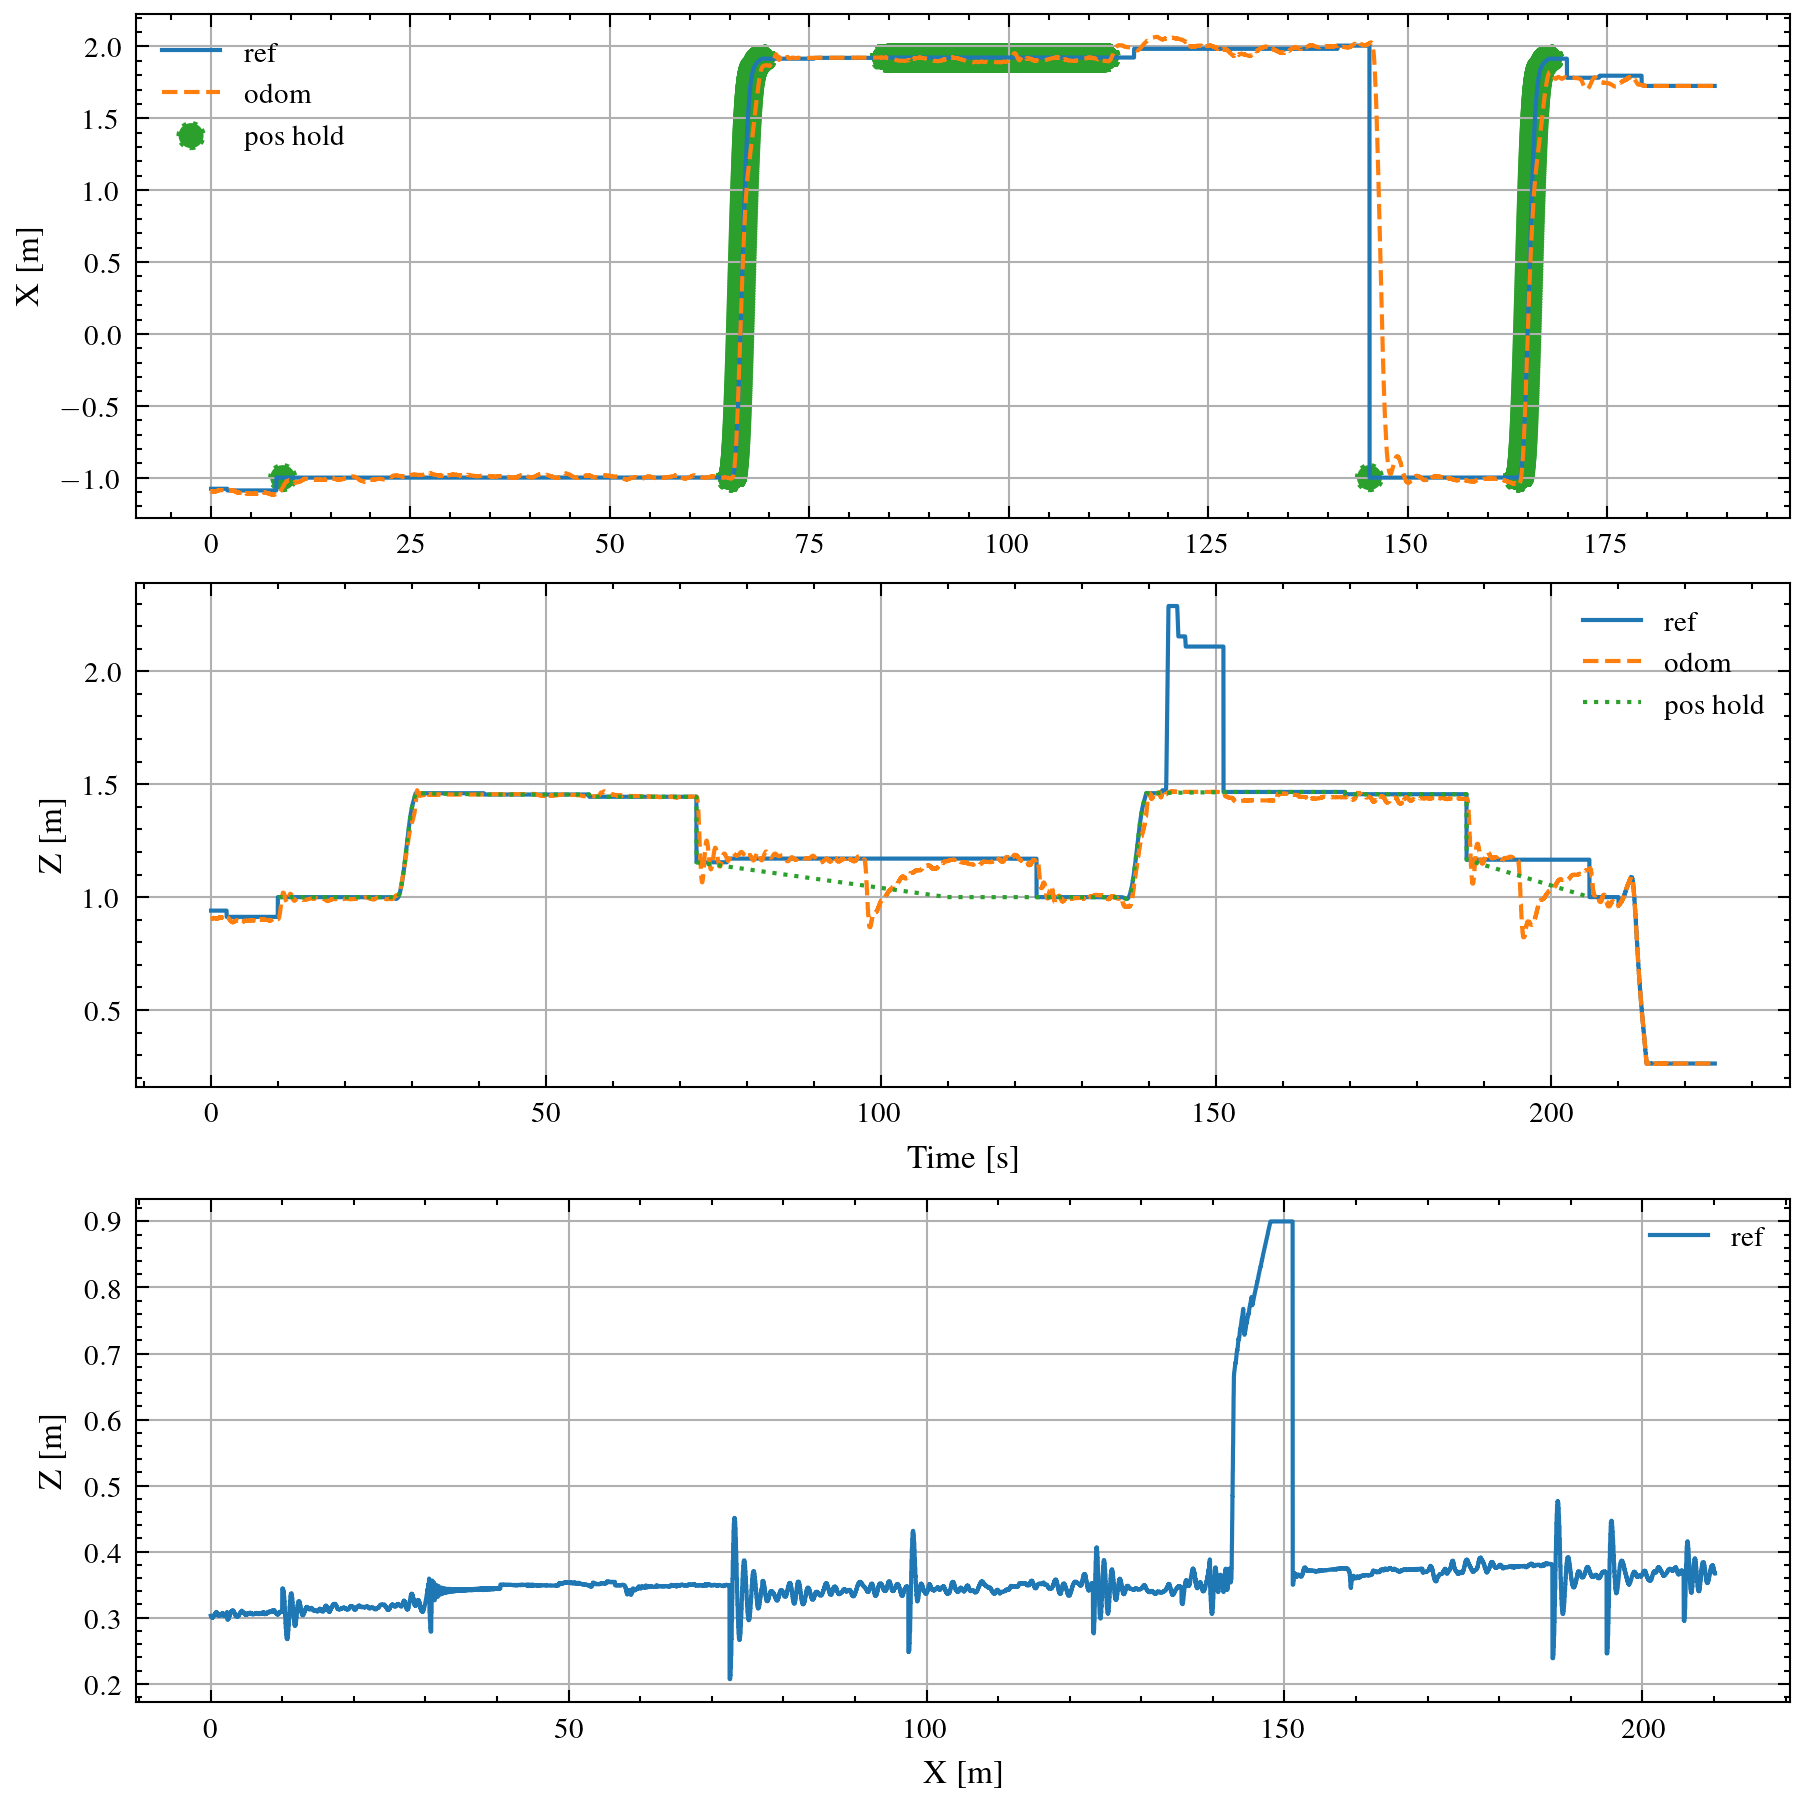

In [63]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6), dpi=300, constrained_layout=True, sharex=False)

axs[0].plot(ref2['Time'], ref2['pose.position.x'], label='ref', color='tab:blue')
axs[0].plot(odom2['Time'], odom2['pose.pose.position.x'], label='odom', color='tab:orange', linestyle='--')
axs[0].scatter(pos_hold2['Time'], pos_hold2['pose.position.x'], label='pos hold', color='tab:green', linestyle=':')
axs[0].set_ylabel('X [m]')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(ref1['Time'], ref1['pose.position.z'], label='ref', color='tab:blue')
axs[1].plot(odom1['Time'], odom1['pose.pose.position.z'], label='odom', color='tab:orange', linestyle='--')
axs[1].plot(pos_hold1['Time'], pos_hold1['pose.position.z'], label='pos hold', color='tab:green', linestyle=':')
axs[1].set_ylabel('Z [m]')
axs[1].set_xlabel('Time [s]')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(control1['Time'], control1['thrust'], label='ref', color='tab:blue')
axs[2].set_ylabel('Z [m]')
axs[2].set_xlabel('X [m]')
axs[2].legend()
axs[2].grid(True)



plt.show()

In [64]:
ts_traj = 26.5 # 135.6
tf_traj = ts_traj + 4.2
ts_opening = 40.7
tf_opening = 72.5

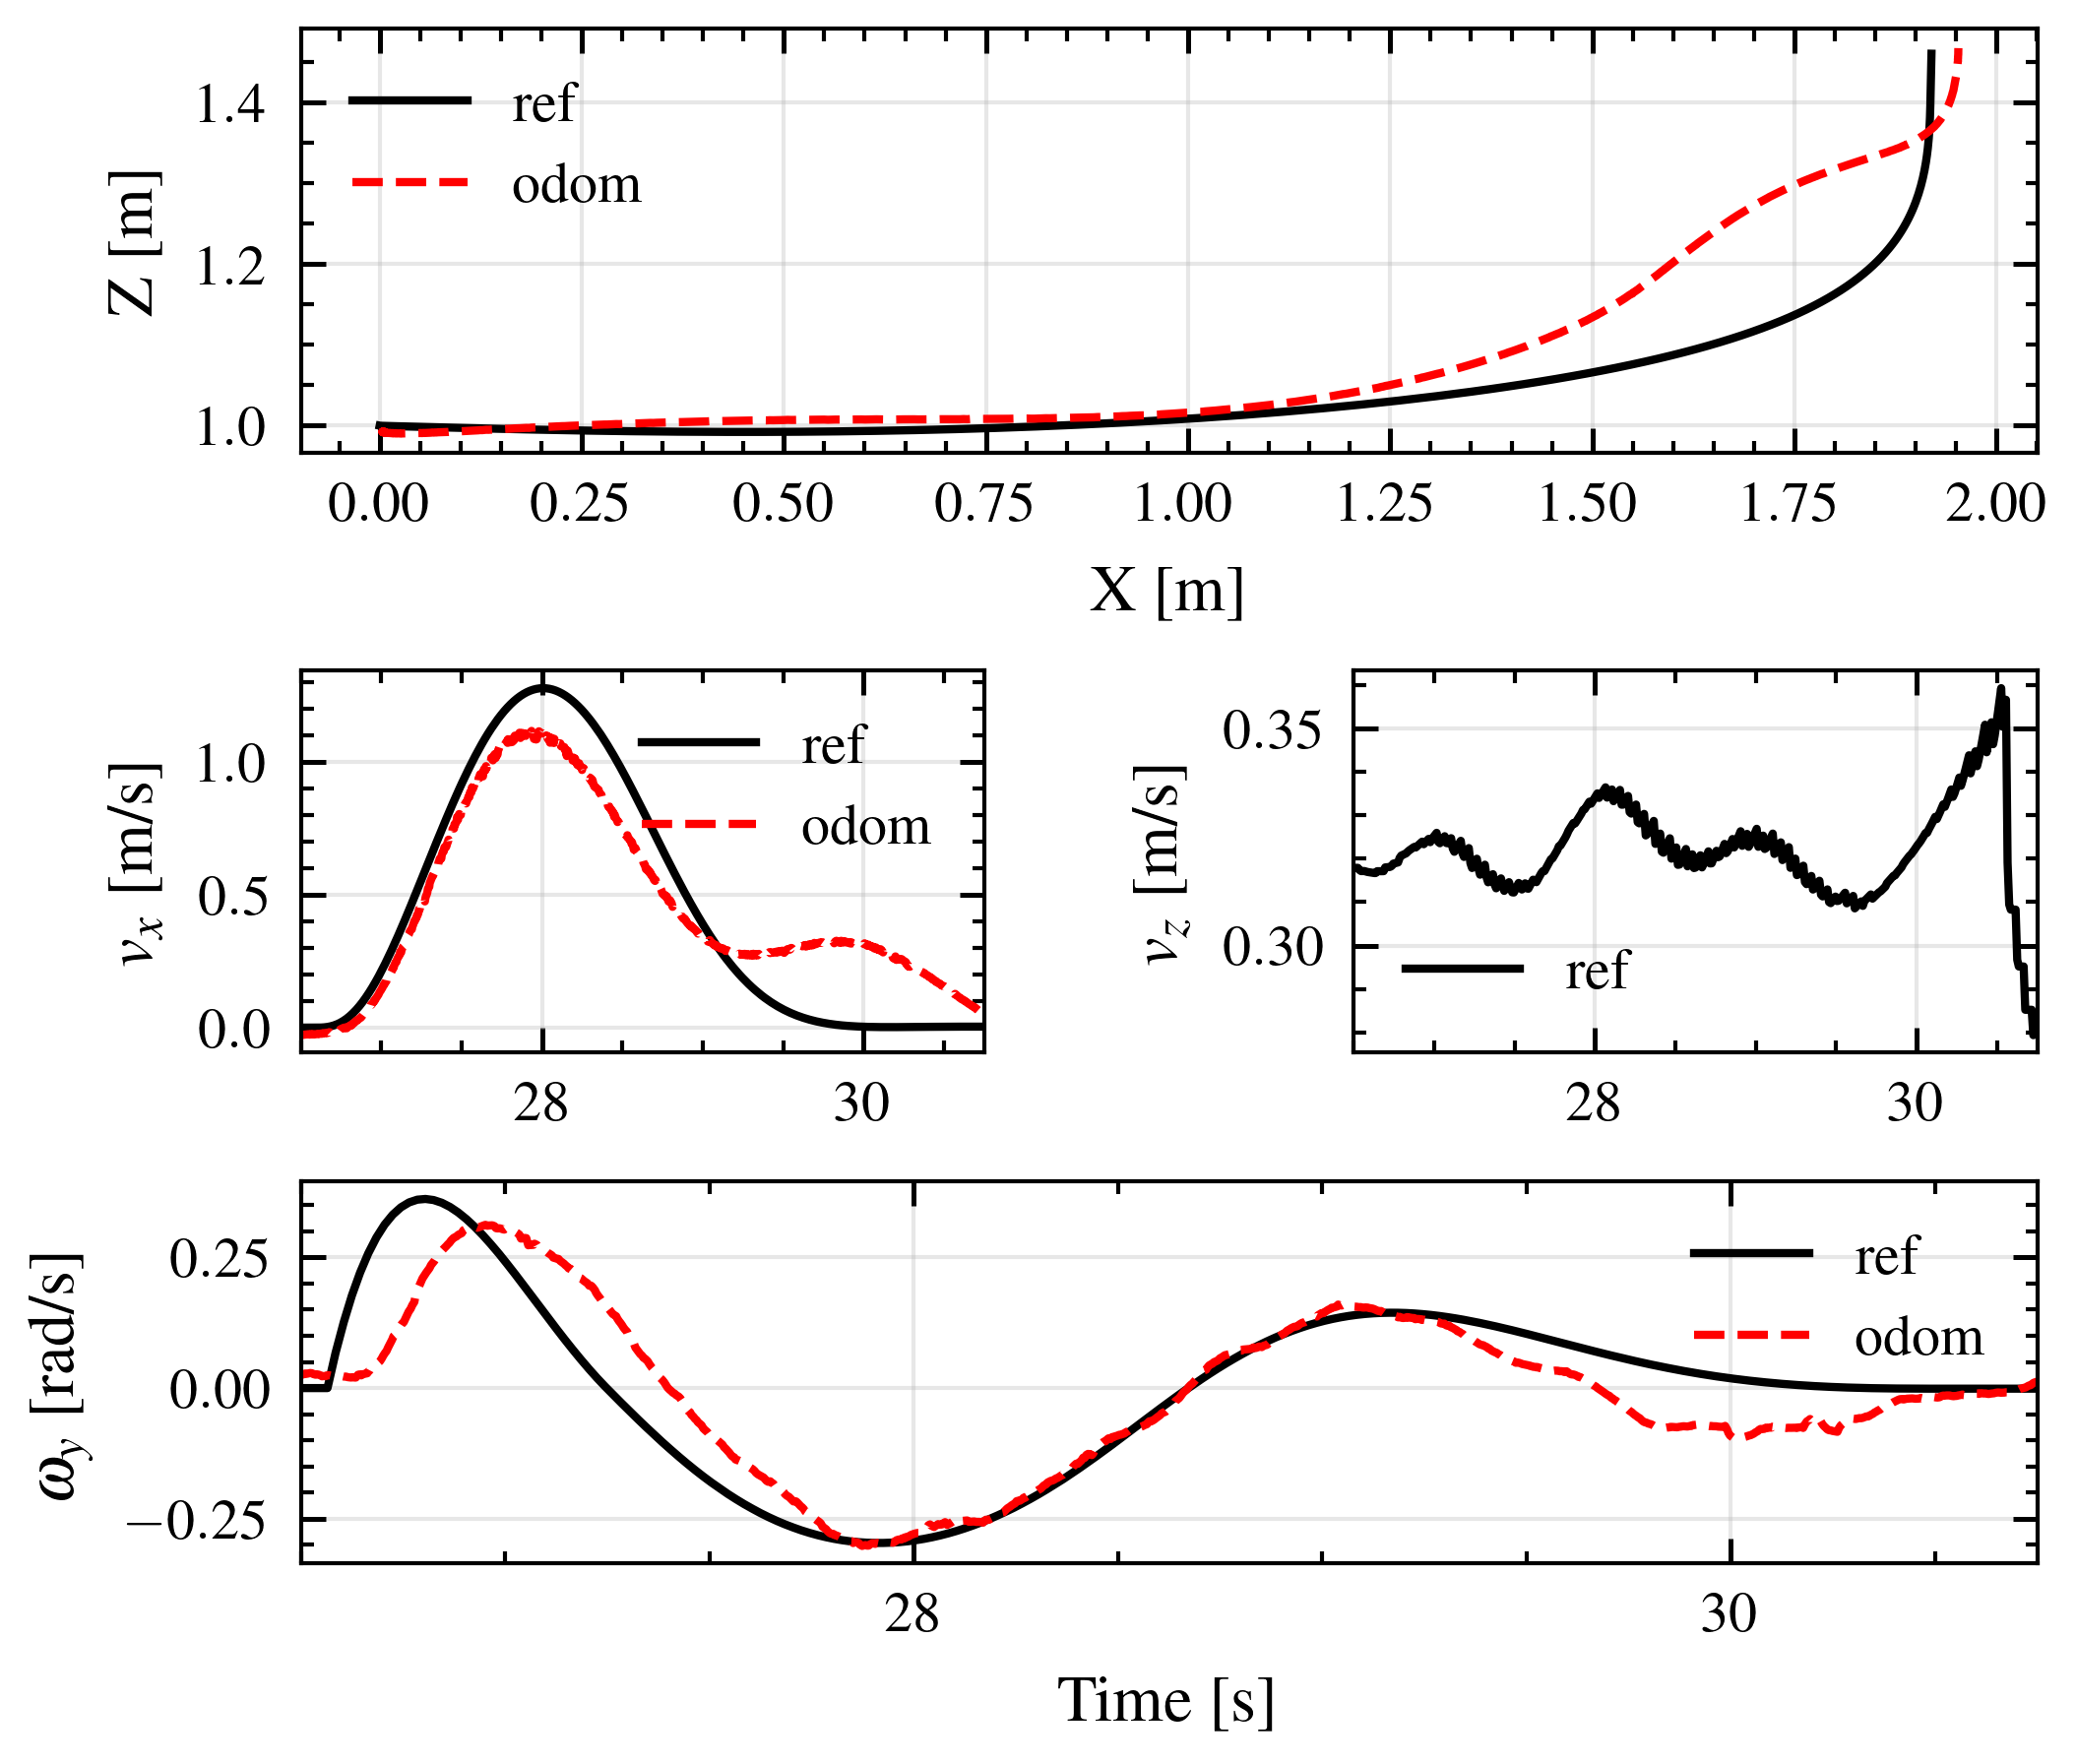

In [65]:
import matplotlib.pyplot as plt

ts_traj = 26.5 # 135.6
tf_traj = ts_traj + 4.25
ts_opening = 40.7
tf_opening = 72.5

# Filter to the requested time window
ref = ref1[(ref1['Time'] >= ts_traj) & (ref1['Time'] <= tf_traj)]
odom = odom1[(odom1['Time'] >= ts_traj) & (odom1['Time'] <= tf_traj)]
control = control1[(control1['Time'] >= ts_traj) & (control1['Time'] <= tf_traj)]

ref_1 = ref
odom_1 = odom
control_1 = control

# Matplotlib defaults suitable for IEEE one-column figures
plt.rcParams.update({
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.0,
})

fig = plt.figure(figsize=(3.5, 3.0), dpi=600, constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1.2, 1.0, 1.0])

# Row 1: position X–Z (spans both columns)
ax_pos = fig.add_subplot(gs[0, :])
ax_pos.plot(ref['pose.position.x'],  ref['pose.position.z'],  label='ref',  linestyle='-')
ax_pos.plot(odom['pose.pose.position.x'], odom['pose.pose.position.z'], label='odom', linestyle='--')
ax_pos.set_xlabel('X [m]')
ax_pos.set_ylabel('Z [m]')
ax_pos.grid(True, alpha=0.3)
ax_pos.legend(loc='best', frameon=False)
ax_pos.set_aspect('equal', adjustable='box')

# Row 2 left: velocity x vs time
ax_vx = fig.add_subplot(gs[1, 0])
ax_vx.plot(ref['Time'],  ref['velocity.linear.x'],          label='ref',  linestyle='-')
ax_vx.plot(odom['Time'], odom['twist.twist.linear.x'],     label='odom', linestyle='--')
ax_vx.set_ylabel(r'$v_x$ [m/s]')
ax_vx.grid(True, alpha=0.3)
ax_vx.set_xlim(ts_traj, tf_traj)
ax_vx.legend(loc='best', frameon=False)

# Row 2 right: velocity z vs time (share x)
ax_vz = fig.add_subplot(gs[1, 1], sharex=ax_vx)
ax_vz.plot(control['Time'],  control['thrust'],          label='ref',  linestyle='-')
#ax_vz.plot(odom['Time'], odom['twist.twist.linear.z'],     label='odom', linestyle='--')
ax_vz.set_ylabel(r'$v_z$ [m/s]')
ax_vz.grid(True, alpha=0.3)
ax_vz.legend(loc='best', frameon=False)

# Row 3: angular y velocity vs time (spans both columns, share x)
ax_wy = fig.add_subplot(gs[2, :], sharex=ax_vx)
ax_wy.plot(ref['Time'],  ref['velocity.angular.y'],         label='ref',  linestyle='-')
ax_wy.plot(odom['Time'], odom['twist.twist.angular.y'],    label='odom', linestyle='--')
ax_wy.set_ylabel(r'$\omega_y$ [rad/s]')
ax_wy.set_xlabel('Time [s]')
ax_wy.grid(True, alpha=0.3)
ax_wy.legend(loc='best', frameon=False)

# Improve tick visibility and avoid duplicate top x-labels
for ax in [ax_pos, ax_vx, ax_vz, ax_wy]:
    ax.tick_params(direction='in', length=3, width=0.6)

plt.show()


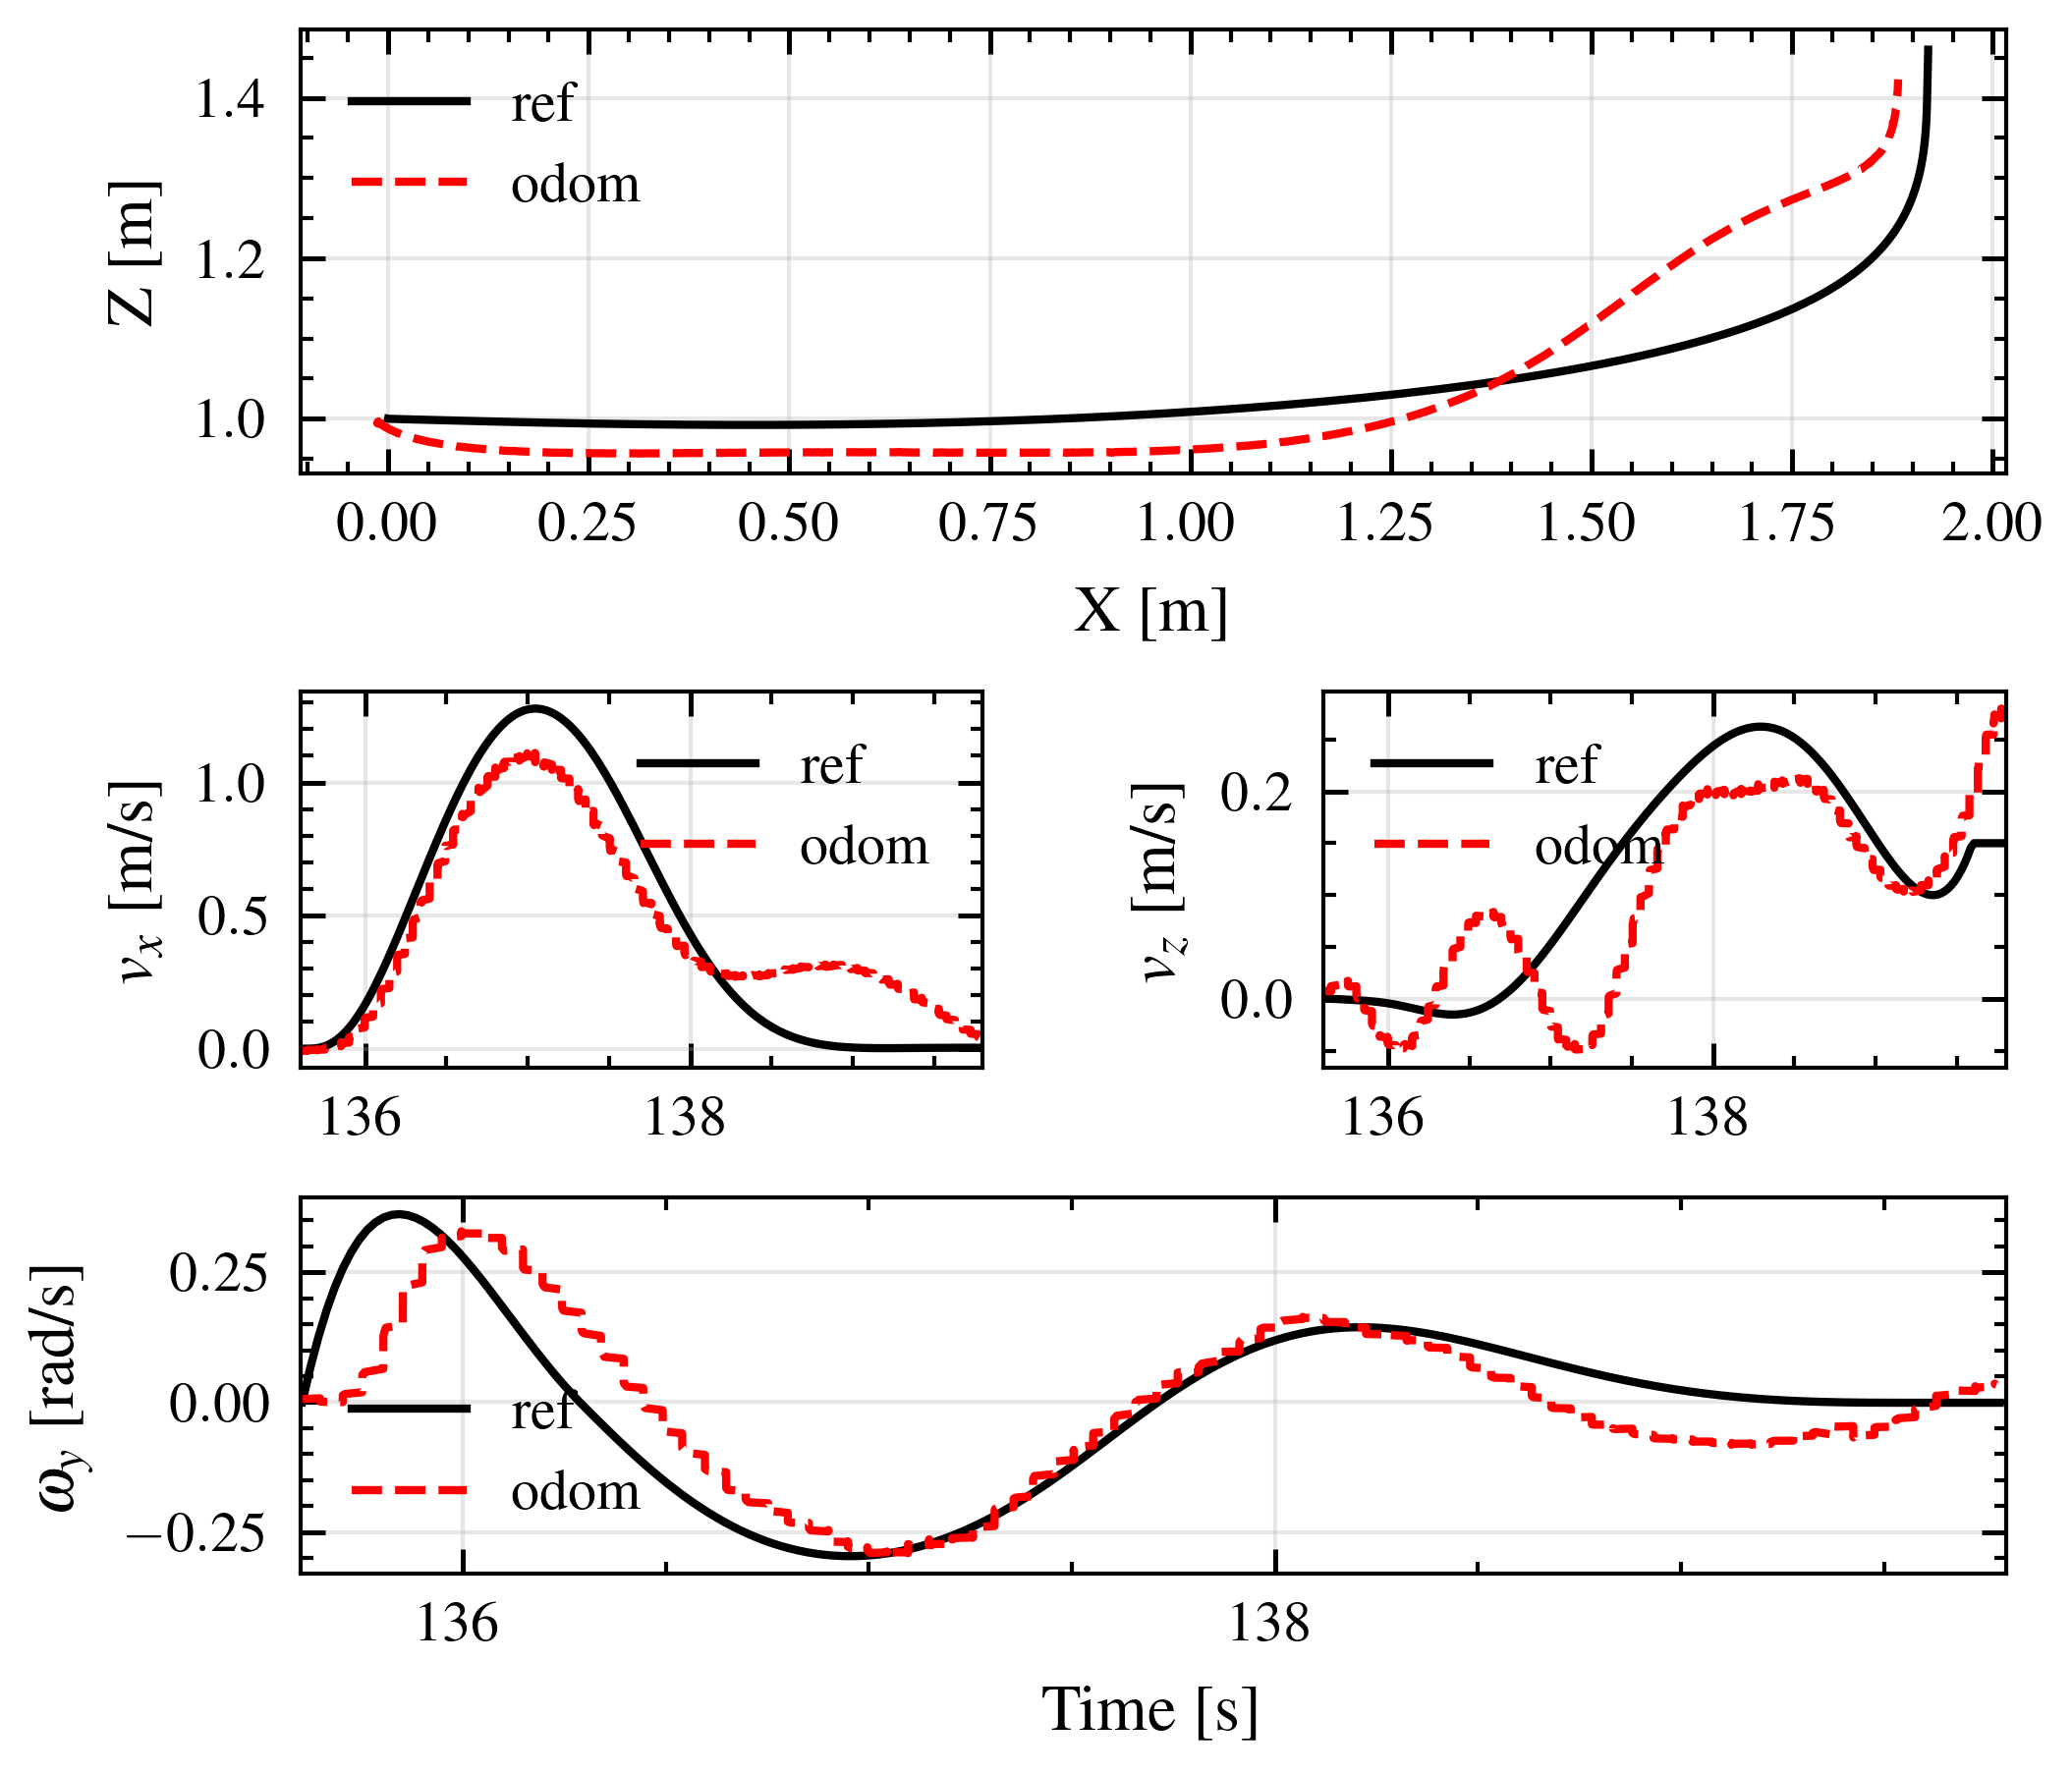

In [55]:
import matplotlib.pyplot as plt

ts_traj = 135.6
tf_traj = ts_traj + 4.2
ts_opening = 40.7
tf_opening = 72.5

# Filter to the requested time window
ref = ref1[(ref1['Time'] >= ts_traj) & (ref1['Time'] <= tf_traj)]
odom = odom1[(odom1['Time'] >= ts_traj) & (odom1['Time'] <= tf_traj)]
control = control1[(control1['Time'] >= ts_traj) & (control1['Time'] <= tf_traj)]

ref_2 = ref
odom_2 = odom
control_2 = control

# Matplotlib defaults suitable for IEEE one-column figures
plt.rcParams.update({
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.0,
})

fig = plt.figure(figsize=(3.5, 3.0), dpi=600, constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1.2, 1.0, 1.0])

# Row 1: position X–Z (spans both columns)
ax_pos = fig.add_subplot(gs[0, :])
ax_pos.plot(ref['pose.position.x'],  ref['pose.position.z'],  label='ref',  linestyle='-')
ax_pos.plot(odom['pose.pose.position.x'], odom['pose.pose.position.z'], label='odom', linestyle='--')
ax_pos.set_xlabel('X [m]')
ax_pos.set_ylabel('Z [m]')
ax_pos.grid(True, alpha=0.3)
ax_pos.legend(loc='best', frameon=False)
ax_pos.set_aspect('equal', adjustable='box')

# Row 2 left: velocity x vs time
ax_vx = fig.add_subplot(gs[1, 0])
ax_vx.plot(ref['Time'],  ref['velocity.linear.x'],          label='ref',  linestyle='-')
ax_vx.plot(odom['Time'], odom['twist.twist.linear.x'],     label='odom', linestyle='--')
ax_vx.set_ylabel(r'$v_x$ [m/s]')
ax_vx.grid(True, alpha=0.3)
ax_vx.set_xlim(ts_traj, tf_traj)
ax_vx.legend(loc='best', frameon=False)

# Row 2 right: velocity z vs time (share x)
ax_vz = fig.add_subplot(gs[1, 1], sharex=ax_vx)
ax_vz.plot(ref['Time'],  ref['velocity.linear.z'],          label='ref',  linestyle='-')
ax_vz.plot(odom['Time'], odom['twist.twist.linear.z'],     label='odom', linestyle='--')
ax_vz.set_ylabel(r'$v_z$ [m/s]')
ax_vz.grid(True, alpha=0.3)
ax_vz.legend(loc='best', frameon=False)

# Row 3: angular y velocity vs time (spans both columns, share x)
ax_wy = fig.add_subplot(gs[2, :], sharex=ax_vx)
ax_wy.plot(ref['Time'],  ref['velocity.angular.y'],         label='ref',  linestyle='-')
ax_wy.plot(odom['Time'], odom['twist.twist.angular.y'],    label='odom', linestyle='--')
ax_wy.set_ylabel(r'$\omega_y$ [rad/s]')
ax_wy.set_xlabel('Time [s]')
ax_wy.grid(True, alpha=0.3)
ax_wy.legend(loc='best', frameon=False)

# Improve tick visibility and avoid duplicate top x-labels
for ax in [ax_pos, ax_vx, ax_vz, ax_wy]:
    ax.tick_params(direction='in', length=3, width=0.6)

plt.show()


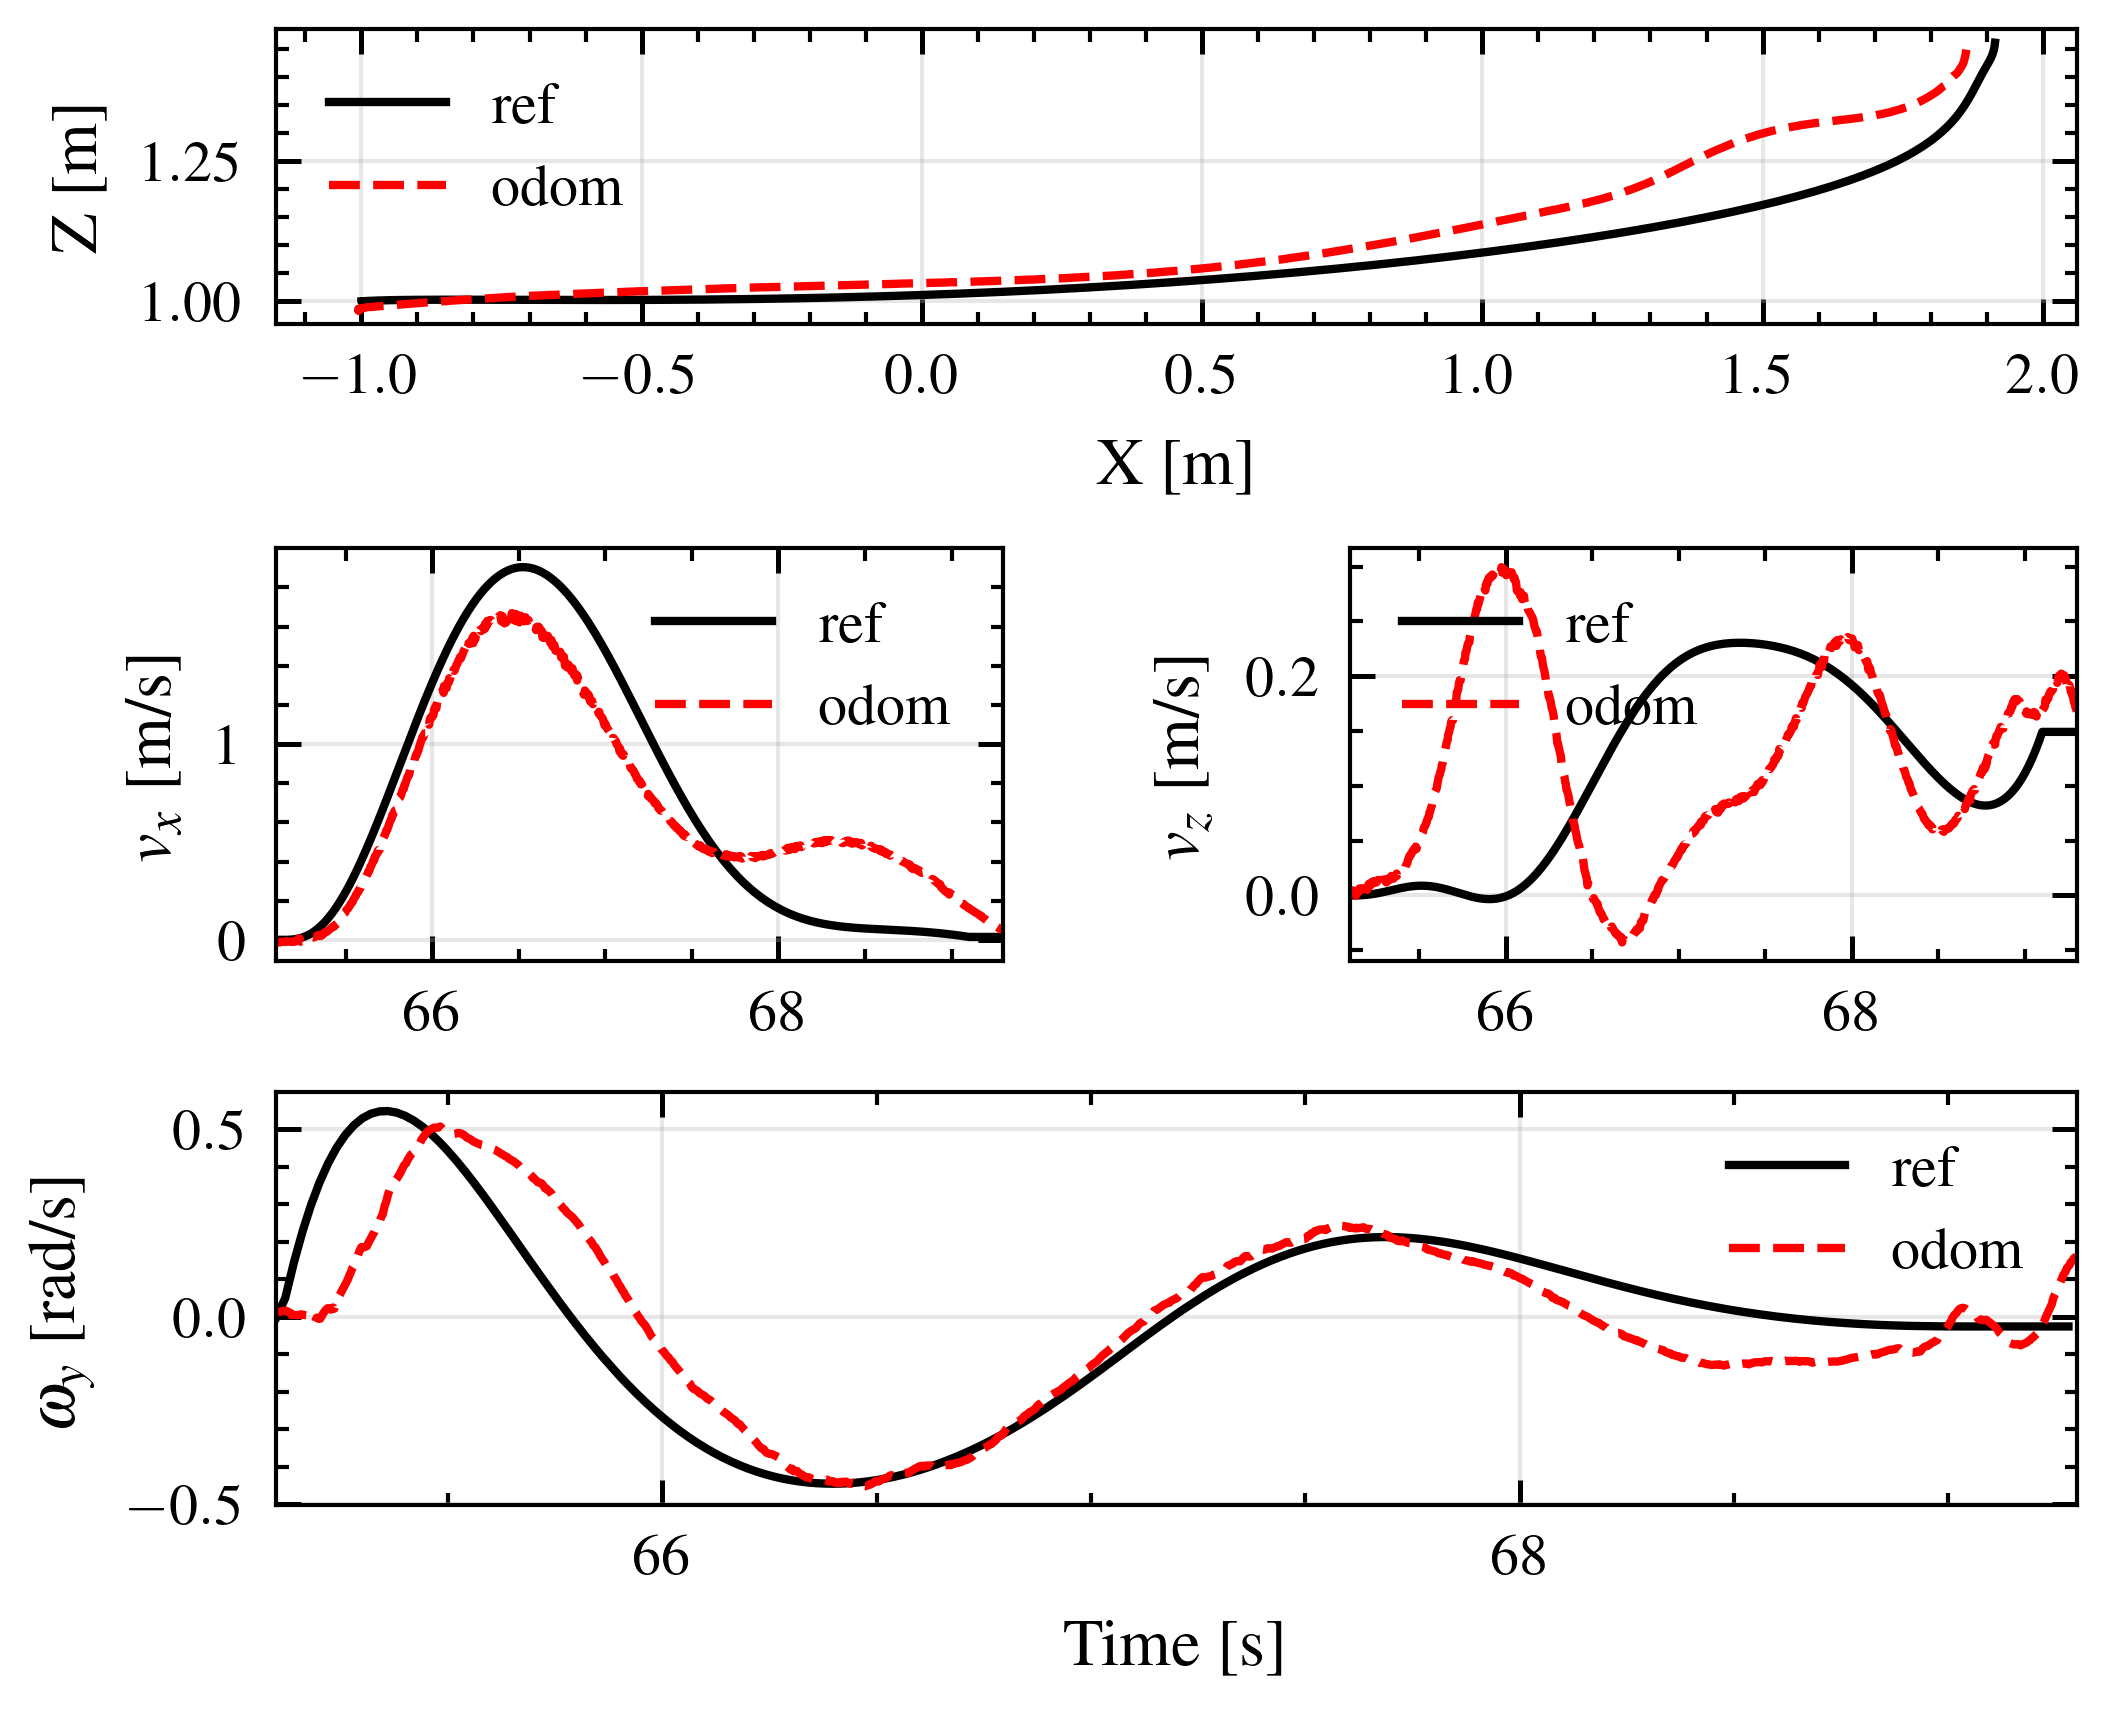

In [56]:
import matplotlib.pyplot as plt

ts_traj = 65.1
tf_traj = ts_traj + 4.2
ts_opening = 40.7
tf_opening = 72.5

# Filter to the requested time window
ref = ref2[(ref2['Time'] >= ts_traj) & (ref2['Time'] <= tf_traj)]
odom = odom2[(odom2['Time'] >= ts_traj) & (odom2['Time'] <= tf_traj)]
control = control2[(control2['Time'] >= ts_traj) & (control2['Time'] <= tf_traj)]

ref_3 = ref
odom_3 = odom
control_3 = control

# Matplotlib defaults suitable for IEEE one-column figures
plt.rcParams.update({
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.0,
})

fig = plt.figure(figsize=(3.5, 3.0), dpi=600, constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[1.2, 1.0, 1.0])

# Row 1: position X–Z (spans both columns)
ax_pos = fig.add_subplot(gs[0, :])
ax_pos.plot(ref['pose.position.x'],  ref['pose.position.z'],  label='ref',  linestyle='-')
ax_pos.plot(odom['pose.pose.position.x'], odom['pose.pose.position.z'], label='odom', linestyle='--')
ax_pos.set_xlabel('X [m]')
ax_pos.set_ylabel('Z [m]')
ax_pos.grid(True, alpha=0.3)
ax_pos.legend(loc='best', frameon=False)
ax_pos.set_aspect('equal', adjustable='box')

# Row 2 left: velocity x vs time
ax_vx = fig.add_subplot(gs[1, 0])
ax_vx.plot(ref['Time'],  ref['velocity.linear.x'],          label='ref',  linestyle='-')
ax_vx.plot(odom['Time'], odom['twist.twist.linear.x'],     label='odom', linestyle='--')
ax_vx.set_ylabel(r'$v_x$ [m/s]')
ax_vx.grid(True, alpha=0.3)
ax_vx.set_xlim(ts_traj, tf_traj)
ax_vx.legend(loc='best', frameon=False)

# Row 2 right: velocity z vs time (share x)
ax_vz = fig.add_subplot(gs[1, 1], sharex=ax_vx)
ax_vz.plot(ref['Time'],  ref['velocity.linear.z'],          label='ref',  linestyle='-')
ax_vz.plot(odom['Time'], odom['twist.twist.linear.z'],     label='odom', linestyle='--')
ax_vz.set_ylabel(r'$v_z$ [m/s]')
ax_vz.grid(True, alpha=0.3)
ax_vz.legend(loc='best', frameon=False)

# Row 3: angular y velocity vs time (spans both columns, share x)
ax_wy = fig.add_subplot(gs[2, :], sharex=ax_vx)
ax_wy.plot(ref['Time'],  ref['velocity.angular.y'],         label='ref',  linestyle='-')
ax_wy.plot(odom['Time'], odom['twist.twist.angular.y'],    label='odom', linestyle='--')
ax_wy.set_ylabel(r'$\omega_y$ [rad/s]')
ax_wy.set_xlabel('Time [s]')
ax_wy.grid(True, alpha=0.3)
ax_wy.legend(loc='best', frameon=False)

# Improve tick visibility and avoid duplicate top x-labels
for ax in [ax_pos, ax_vx, ax_vz, ax_wy]:
    ax.tick_params(direction='in', length=3, width=0.6)

plt.show()


In [57]:
ref_1 = ref_1.reset_index(drop=True)
odom_1 = odom_1.reset_index(drop=True)
control_1 = control_1.reset_index(drop=True)

odom_time = odom_1['Time']
ref_1['Time'] = ref_1['Time'] - odom_time
control_1['Time'] = control_1['Time'] - odom_time
odom_1['Time'] = odom_1['Time'] - odom_time


ref_2 = ref_2.reset_index(drop=True)
odom_2 = odom_2.reset_index(drop=True)
control_2 = control_2.reset_index(drop=True)

odom_time = odom_2['Time']
ref_2['Time'] = ref_2['Time'] - odom_time
control_2['Time'] = control_2['Time'] - odom_time
odom_2['Time'] = odom_2['Time'] - odom_time

ref_3 = ref_3.reset_index(drop=True)
odom_3 = odom_3.reset_index(drop=True)
control_3 = control_3.reset_index(drop=True)

odom_time = odom_3['Time']
ref_3['Time'] = ref_3['Time'] - odom_time
control_3['Time'] = control_3['Time'] - odom_time
odom_3['Time'] = odom_3['Time'] - odom_time

odom_1

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,child_frame_id,pose.pose.position.x,pose.pose.position.y,pose.pose.position.z,pose.pose.orientation.x,...,pose.pose.orientation.z,pose.pose.orientation.w,pose.covariance,twist.twist.linear.x,twist.twist.linear.y,twist.twist.linear.z,twist.twist.angular.x,twist.twist.angular.y,twist.twist.angular.z,twist.covariance
0,0.0,75030,1757093522,967400600,optitrack,red,0.007284,-0.011999,0.991673,0.000873,...,0.001131,-0.999985,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-0.026188,-0.019183,0.005613,-0.009869,0.025186,-0.006908,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,0.0,75031,1757093522,971409573,optitrack,red,0.006962,-0.012157,0.991705,0.001069,...,0.000907,-0.999984,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-0.028366,-0.019993,0.005648,-0.011527,0.026715,-0.004698,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,0.0,75032,1757093522,976405803,optitrack,red,0.006883,-0.012303,0.991760,0.001240,...,0.000952,-0.999982,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-0.027737,-0.020461,0.005890,-0.012854,0.027901,-0.005008,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,0.0,75033,1757093522,980401985,optitrack,red,0.006873,-0.012268,0.991862,0.001032,...,0.000918,-0.999983,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-0.026746,-0.019293,0.006676,-0.010677,0.027337,-0.004589,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,0.0,75034,1757093522,984457087,optitrack,red,0.006755,-0.012339,0.991810,0.001123,...,0.001048,-0.999982,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-0.026832,-0.019228,0.005866,-0.011323,0.028198,-0.005724,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,0.0,76045,1757093527,199402428,optitrack,red,1.952686,0.019316,1.462919,-0.003303,...,0.009507,-0.999787,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.055814,0.016904,0.278382,-0.004420,0.005642,-0.012309,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1016,0.0,76046,1757093527,203403255,optitrack,red,1.952609,0.019193,1.463996,-0.003032,...,0.009665,-0.999792,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.053055,0.014927,0.278081,-0.006915,0.008345,-0.013518,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1017,0.0,76047,1757093527,206402867,optitrack,red,1.952704,0.019398,1.465075,-0.002942,...,0.009689,-0.999795,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.052648,0.016563,0.280500,-0.007678,0.010016,-0.013544,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1018,0.0,76048,1757093527,209402083,optitrack,red,1.952730,0.019452,1.466008,-0.002920,...,0.009684,-0.999797,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.051577,0.016652,0.281409,-0.007781,0.010872,-0.013303,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


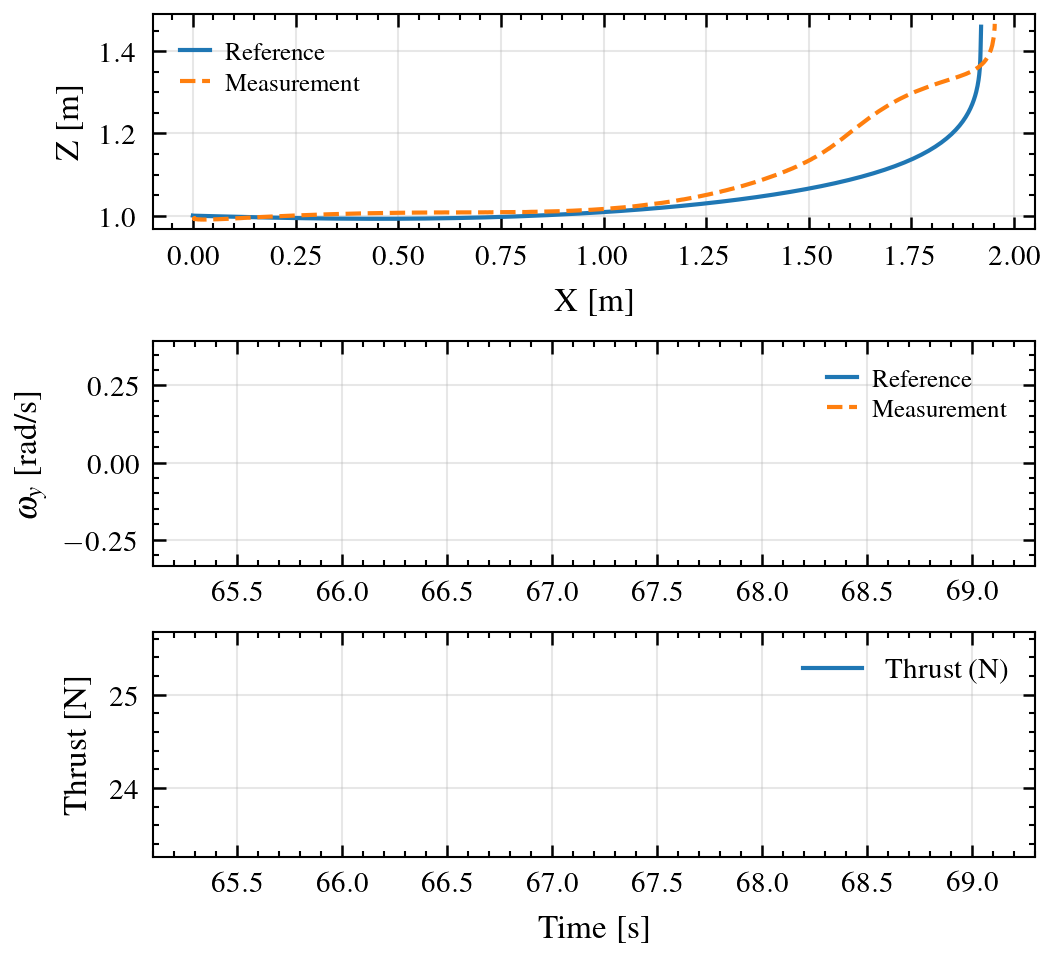

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A = 0.6142
B = -1.2010

ref = ref_1
odom = odom_1
control = control_1

# --- Normalize->Force and de-spike ---
u = np.clip(control['thrust'].to_numpy(), 0.0, 1.0)        # ensure [0,1]
F_raw = (((u - B) / A)**2 ) * 4                                 # F in Newtons
control['thrust_N_raw'] = F_raw

# choose window from median dt (~50 ms target)
t = control['Time'].to_numpy()
if len(t) >= 3:
    dt_med = float(np.median(np.diff(t)))
    k = max(3, int(round(0.05 / dt_med)))                  # ~50 ms
else:
    k = 15
if k % 2 == 0:
    k += 1

t0 = ts_traj
ref_time     = ref['Time'] - t0
odom_time    = odom['Time'] - t0
control_time = control['Time'] - t0

    
# rolling median then mean (centered)
F_med = pd.Series(F_raw).rolling(window=k, center=True, min_periods=1).median()
F_smooth = F_med.rolling(window=k, center=True, min_periods=5).mean().to_numpy()
control['thrust_N'] = F_smooth

# --- Plot (IEEE one-column) ---
plt.rcParams.update({
    "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "lines.linewidth": 1.0,
})

fig = plt.figure(figsize=(3.5, 3.2), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1.0, 1.0, 1.0])

# Row 1: X–Z
ax_xz = fig.add_subplot(gs[0, 0])
ax_xz.plot(ref['pose.position.x'], ref['pose.position.z'], label='Reference', linestyle='-', color='tab:blue')
ax_xz.plot(odom['pose.pose.position.x'], odom['pose.pose.position.z'], label='Measurement', linestyle='--', color='tab:orange')
ax_xz.set_xlabel('X [m]'); ax_xz.set_ylabel('Z [m]')
ax_xz.grid(True, alpha=0.3); ax_xz.legend(frameon=False, loc='best')
ax_xz.set_aspect('equal', adjustable='box')

# Row 2: ω_y – t
ax_wy = fig.add_subplot(gs[1, 0])
ax_wy.plot(ref_time, ref['velocity.angular.y'], label='Reference', linestyle='-', color='tab:blue')
ax_wy.plot(odom_time, odom['twist.twist.angular.y'], label='Measurement', linestyle='--', color='tab:orange')
ax_wy.set_xlim(ts_traj, tf_traj)
ax_wy.set_ylabel(r'$\omega_y$ [rad/s]')
ax_wy.grid(True, alpha=0.3); ax_wy.legend(frameon=False, loc='best')

# Row 3: Thrust (N) – t
ax_th = fig.add_subplot(gs[2, 0], sharex=ax_wy)
ax_th.plot(control_time, control['thrust_N'], label='Thrust (N)', linestyle='-', color='tab:blue')
ax_th.set_xlabel('Time [s]'); ax_th.set_ylabel('Thrust [N]')
ax_th.grid(True, alpha=0.3); ax_th.legend(frameon=False, loc='best')

lgd = ax_xz.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax_xz.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper left",          # try "lower left" if it overlaps
    ncol=1,                     # or 3 to make a single-row legend
    frameon=False,               # draw box
    fancybox=False,              # rounded corners
    framealpha=0.9,             # box opacity
    facecolor="white",          # box fill
    edgecolor="0.3",            # border color
    borderpad=0.6,              # padding inside box
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)

lgd = ax_wy.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax_wy.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper right",          # try "lower left" if it overlaps
    ncol=1,                     # or 3 to make a single-row legend
    frameon=False,               # draw box
    fancybox=False,              # rounded corners
    framealpha=0.9,             # box opacity
    facecolor="white",          # box fill
    edgecolor="0.3",            # border color
    borderpad=0.6,              # padding inside box
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)


for ax in (ax_xz, ax_wy, ax_th):
    ax.tick_params(direction='in', length=3, width=0.6)

plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


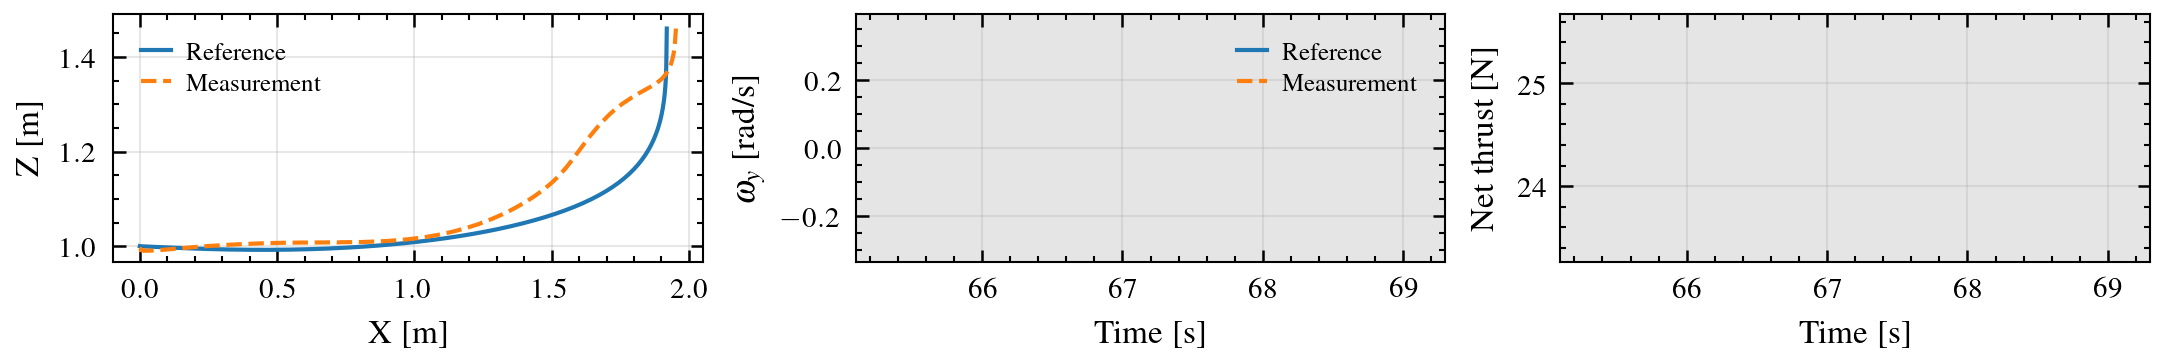

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- params ---
A = 0.6142
B = -1.2010
N_MOTORS = 4  # quad

ref = ref_1
odom = odom_1
control = control_1.copy()

# --- normalized thrust -> total force (N), de-spike ---
u = np.clip(control['thrust'].to_numpy(), 0.0, 1.0)
F_total_raw = N_MOTORS * ((u - B) / A)**2
control['thrust_N_raw'] = F_total_raw

t = control['Time'].to_numpy()
if len(t) >= 3:
    dt_med = float(np.median(np.diff(t)))
    k = max(3, int(round(0.05 / dt_med)))  # ~50 ms window
else:
    k = 15
if k % 2 == 0:
    k += 1

F_med = pd.Series(F_total_raw).rolling(window=k, center=True, min_periods=1).median()
F_smooth = F_med.rolling(window=k, center=True, min_periods=1).mean().to_numpy()
control['thrust_N'] = F_smooth

# --- plotting (IEEE two-column width) ---
plt.rcParams.update({
    "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "lines.linewidth": 1.0,
})

fig = plt.figure(figsize=(7.2, 1.2), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1.0, 1.0, 1.0])

# Col 1: X–Z
ax_xz = fig.add_subplot(gs[0, 0])
ax_xz.plot(ref['pose.position.x'], ref['pose.position.z'], label='Reference', linestyle='-', color='tab:blue')
ax_xz.plot(odom['pose.pose.position.x'], odom['pose.pose.position.z'], label='Measurement', linestyle='--', color='tab:orange')
ax_xz.set_xlabel('X [m]'); ax_xz.set_ylabel('Z [m]')
ax_xz.grid(True, alpha=0.3); ax_xz.legend(frameon=False, loc='best')
#ax_xz.set_aspect('equal', adjustable='box')

# Col 2: ω_y – t
ax_wy = fig.add_subplot(gs[0, 1])
ax_wy.plot(ref['Time'], ref['velocity.angular.y'], label='Reference', linestyle='-', color='tab:blue')
ax_wy.plot(odom['Time'], odom['twist.twist.angular.y'], label='Measurement', linestyle='--', color='tab:orange')
ax_wy.set_xlim(ts_traj, tf_traj)
ax_wy.set_xlabel('Time [s]'); ax_wy.set_ylabel(r'$\omega_y$ [rad/s]')
ax_wy.grid(True, alpha=0.3); ax_wy.legend(frameon=False, loc='best')

# Col 3: Thrust (N) – t (share x with Col 2)
ax_th = fig.add_subplot(gs[0, 2], sharex=ax_wy)
ax_th.plot(control['Time'], control['thrust_N'], linestyle='-', color='tab:blue')
ax_th.set_xlabel('Time [s]'); ax_th.set_ylabel('Net thrust [N]')
ax_th.grid(True, alpha=0.3); ax_th.legend(frameon=False, loc='best')

# Optional highlight interval
try:
    for ax in (ax_wy, ax_th):
        ax.axvspan(ts_opening, tf_opening, alpha=0.10)
except NameError:
    pass

for ax in (ax_xz, ax_wy, ax_th):
    ax.tick_params(direction='in', length=3, width=0.6)


lgd = ax_xz.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax_xz.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper left",          # try "lower left" if it overlaps
    ncol=1,                     # or 3 to make a single-row legend
    frameon=False,               # draw box
    fancybox=False,              # rounded corners
    framealpha=0.9,             # box opacity
    facecolor="white",          # box fill
    edgecolor="0.3",            # border color
    borderpad=0.6,              # padding inside box
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)

lgd = ax_wy.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax_wy.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper right",          # try "lower left" if it overlaps
    ncol=1,                     # or 3 to make a single-row legend
    frameon=False,               # draw box
    fancybox=False,              # rounded corners
    framealpha=0.9,             # box opacity
    facecolor="white",          # box fill
    edgecolor="0.3",            # border color
    borderpad=0.6,              # padding inside box
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)

#for ax in (ax_xz, ax_wy, ax_th):
#    ax.spines['top'].set_visible(False)
#    ax.spines['right'].set_visible(False)
#    ax.tick_params(top=False, right=False, direction='in', length=3, width=0.6)
#    ax.set_axisbelow(True)

plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


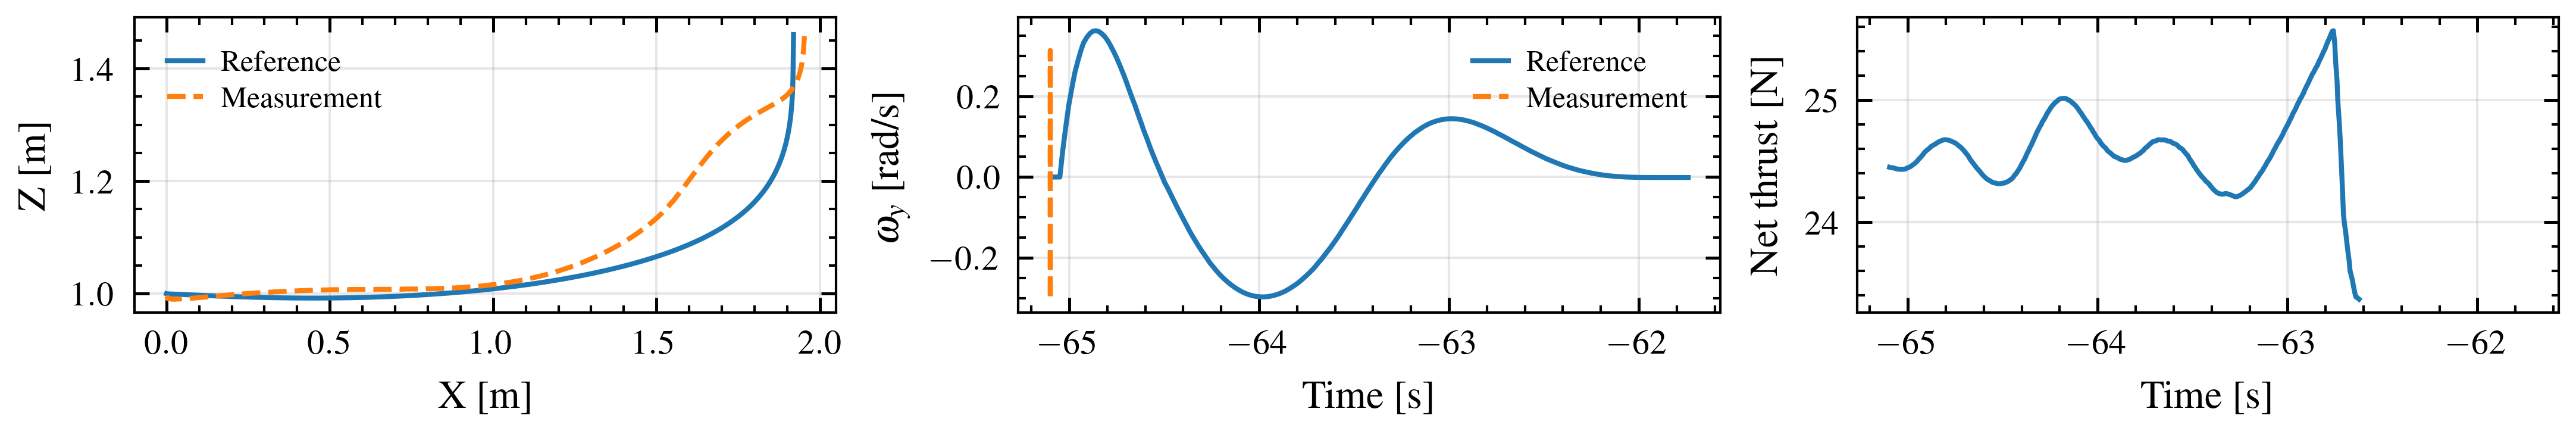

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- params ---
A = 0.6142
B = -1.2010
N_MOTORS = 4  # quad

ref = ref_1
odom = odom_1
control = control_1.copy()

# --- normalized thrust -> total force (N), de-spike ---
u = np.clip(control['thrust'].to_numpy(), 0.0, 1.0)
F_total_raw = N_MOTORS * ((u - B) / A)**2
control['thrust_N_raw'] = F_total_raw

t = control['Time'].to_numpy()
if len(t) >= 3:
    dt_med = float(np.median(np.diff(t)))
    k = max(3, int(round(0.05 / dt_med)))  # ~50 ms window
else:
    k = 15
if k % 2 == 0:
    k += 1

F_med = pd.Series(F_total_raw).rolling(window=k, center=True, min_periods=1).median()
F_smooth = F_med.rolling(window=k, center=True, min_periods=1).mean().to_numpy()
control['thrust_N'] = F_smooth

# --- shift time so plots start at t=0 ---
t0 = ts_traj
ref_time     = ref['Time'] - t0
odom_time    = odom['Time'] - t0
control_time = control['Time'] - t0
# we will also use (tf_traj - ts_traj) for x-limits

# --- plotting (IEEE two-column width) ---
plt.rcParams.update({
    "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "lines.linewidth": 1.0,
})

fig = plt.figure(figsize=(7.2, 1.2), dpi=600, constrained_layout=True)
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1.0, 1.0, 1.0])

# Col 1: X–Z
ax_xz = fig.add_subplot(gs[0, 0])
ax_xz.plot(ref['pose.position.x'], ref['pose.position.z'], label='Reference', linestyle='-', color='tab:blue')
ax_xz.plot(odom['pose.pose.position.x'], odom['pose.pose.position.z'], label='Measurement', linestyle='--', color='tab:orange')
ax_xz.set_xlabel('X [m]'); ax_xz.set_ylabel('Z [m]')
ax_xz.grid(True, alpha=0.3); ax_xz.legend(frameon=False, loc='best')
#ax_xz.set_aspect('equal', adjustable='box')

# Col 2: ω_y – t (now starts at 0)
ax_wy = fig.add_subplot(gs[0, 1])
ax_wy.plot(ref_time, ref['velocity.angular.y'], label='Reference', linestyle='-', color='tab:blue')
ax_wy.plot(odom_time, odom['twist.twist.angular.y'], label='Measurement', linestyle='--', color='tab:orange')
# ax_wy.set_xlim(0.0, tf_traj - ts_traj)
ax_wy.set_xlabel('Time [s]'); ax_wy.set_ylabel(r'$\omega_y$ [rad/s]')
ax_wy.grid(True, alpha=0.3); ax_wy.legend(frameon=False, loc='best')

# Col 3: Thrust (N) – t (share x with Col 2, starts at 0)
ax_th = fig.add_subplot(gs[0, 2], sharex=ax_wy)
ax_th.plot(control_time, control['thrust_N'], linestyle='-', color='tab:blue')
ax_th.set_xlabel('Time [s]'); ax_th.set_ylabel('Net thrust [N]')
ax_th.grid(True, alpha=0.3); ax_th.legend(frameon=False, loc='best')



for ax in (ax_xz, ax_wy, ax_th):
    ax.tick_params(direction='in', length=3, width=0.6)

lgd = ax_xz.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax_xz.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper left",
    ncol=1,
    frameon=False,
    fancybox=False,
    framealpha=0.9,
    facecolor="white",
    edgecolor="0.3",
    borderpad=0.6,
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)

lgd = ax_wy.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax_wy.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper right",
    ncol=1,
    frameon=False,
    fancybox=False,
    framealpha=0.9,
    facecolor="white",
    edgecolor="0.3",
    borderpad=0.6,
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)

#for ax in (ax_xz, ax_wy, ax_th):
#    ax.spines['top'].set_visible(False)
#    ax.spines['right'].set_visible(False)
#    ax.tick_params(top=False, right=False, direction='in', length=3, width=0.6)
#    ax.set_axisbelow(True)

plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


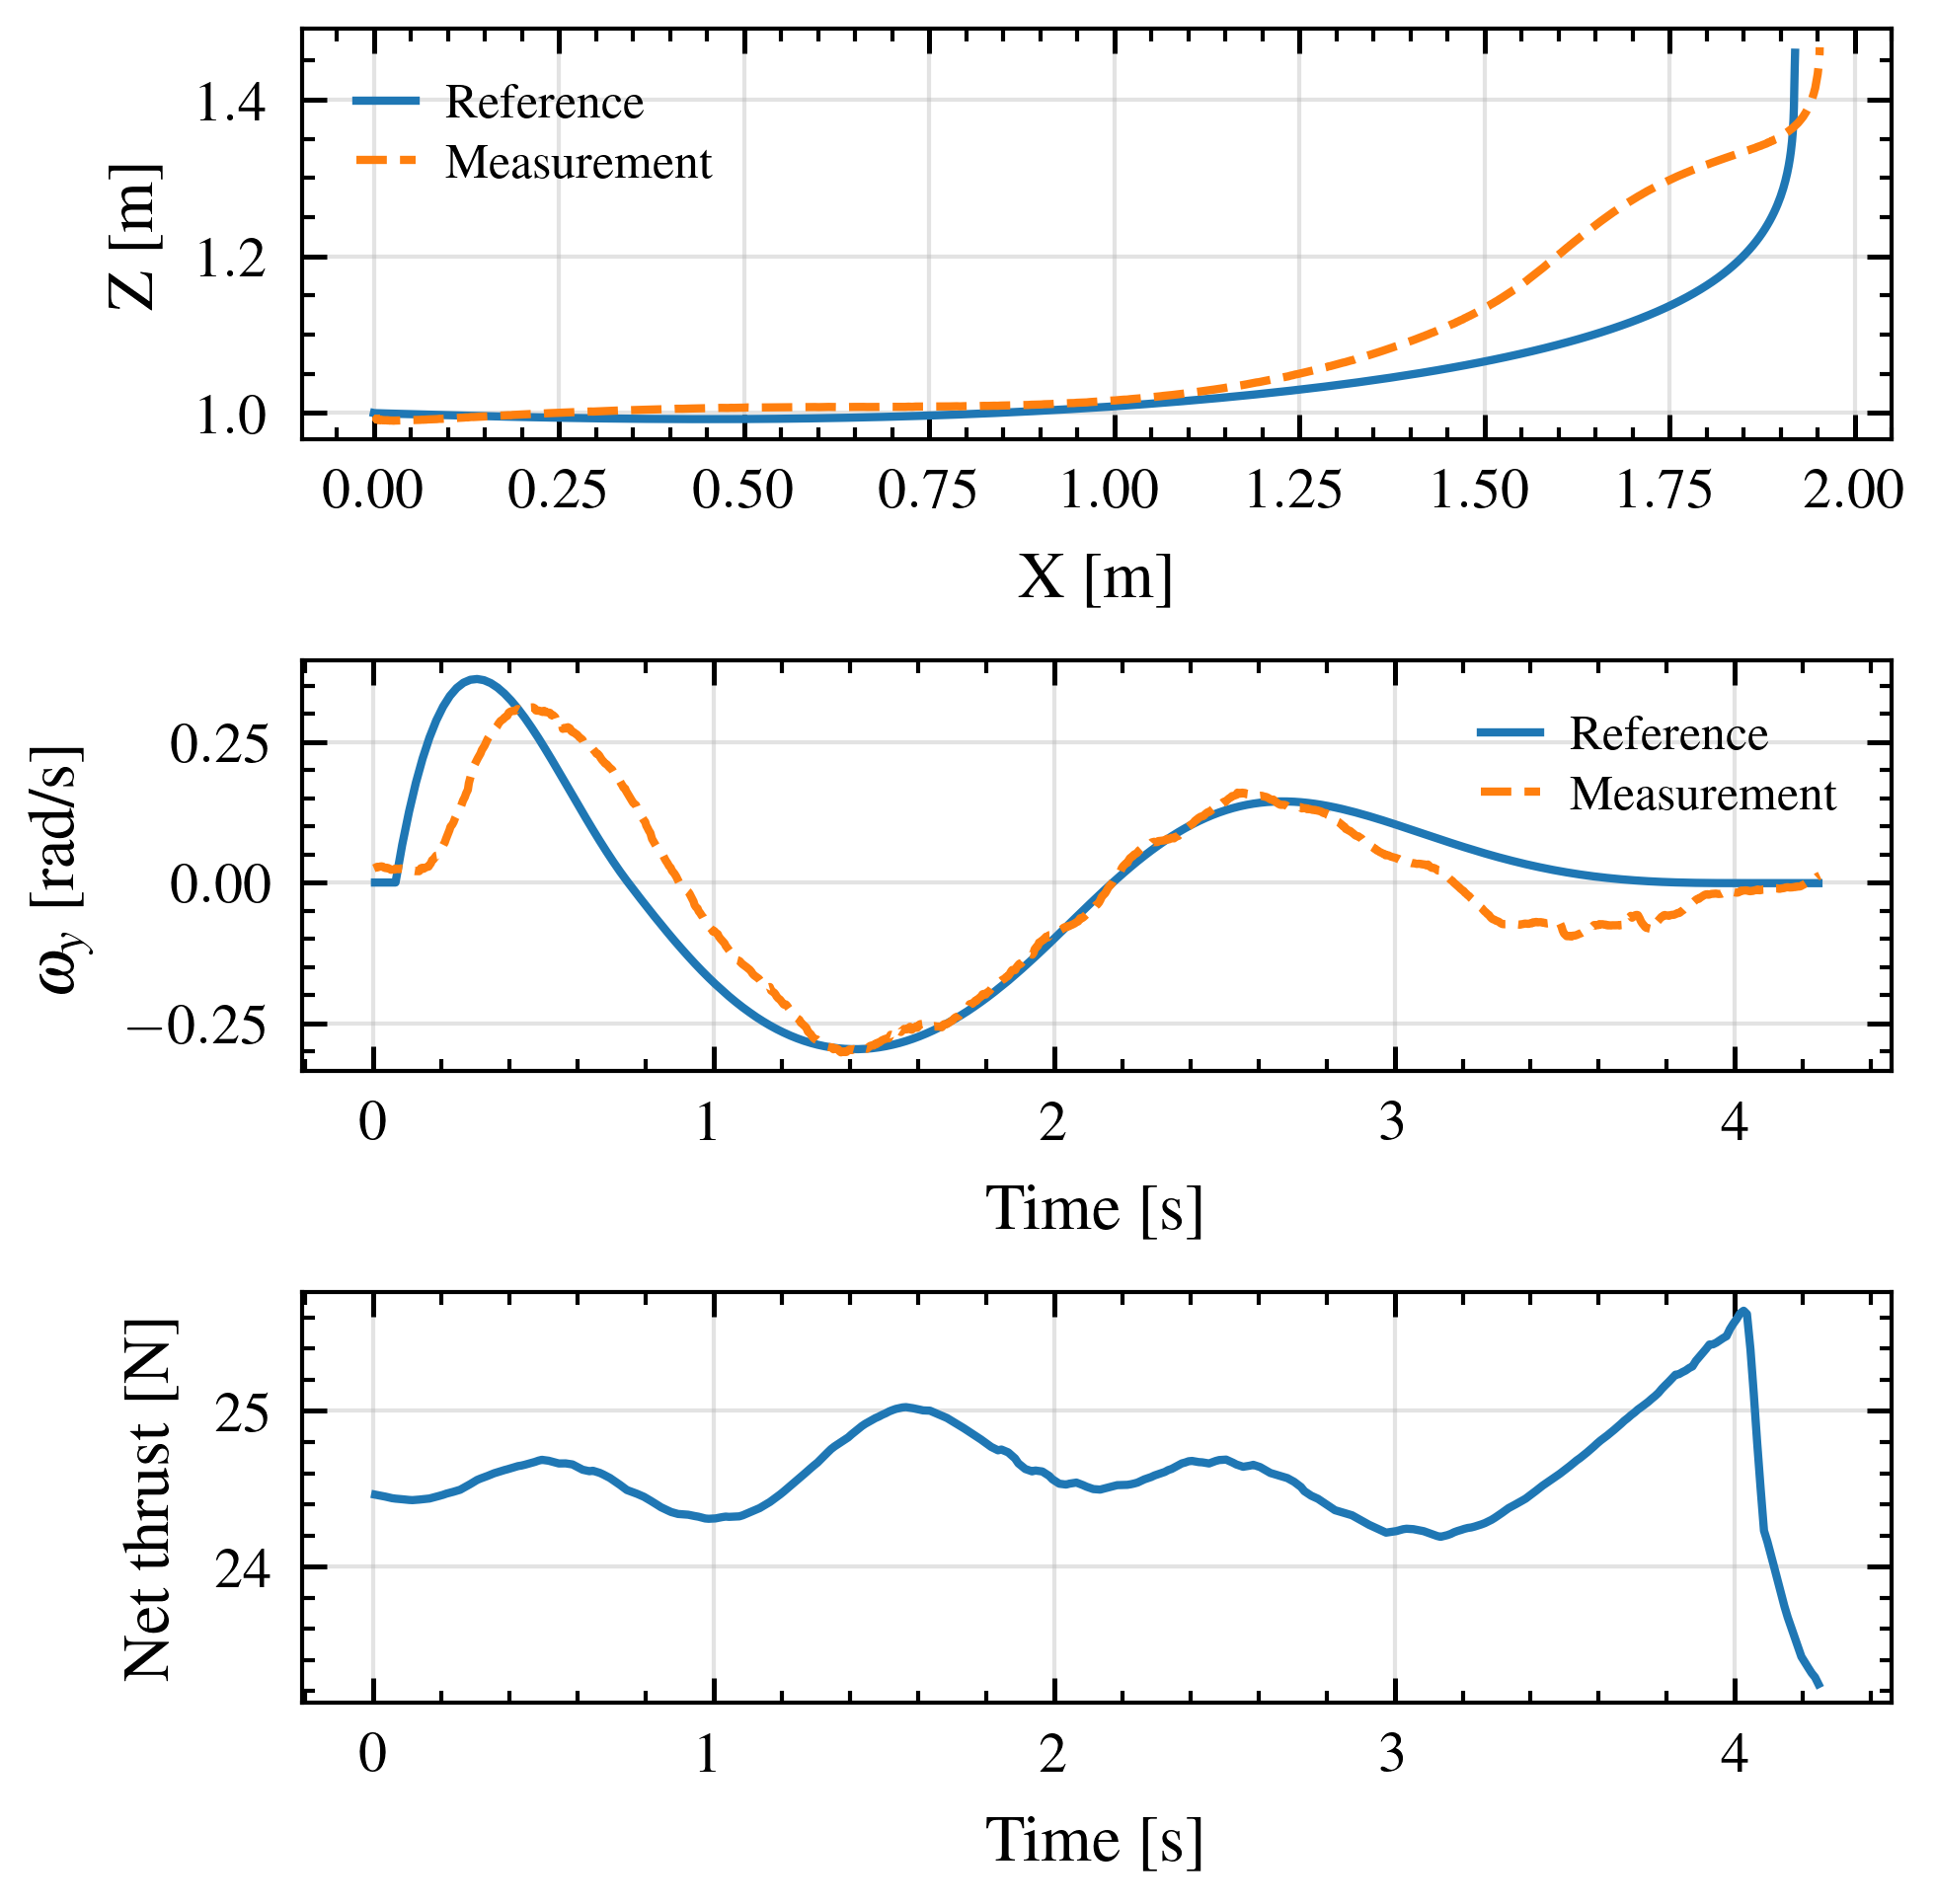

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- params ---
A = 0.6142
B = -1.2010
N_MOTORS = 4  # quad

ref = ref_1.copy()
odom = odom_1.copy()
control = control_1.copy()

# --- normalized thrust -> total force (N), de-spike ---
u = np.clip(control['thrust'].to_numpy(), 0.0, 1.0)
F_total_raw = N_MOTORS * ((u - B) / A)**2
control['thrust_N_raw'] = F_total_raw

t = control['Time'].to_numpy()
if len(t) >= 3:
    dt_med = float(np.median(np.diff(t)))
    k = max(3, int(round(0.05 / dt_med)))  # ~50 ms window
else:
    k = 15
if k % 2 == 0:
    k += 1

F_med = pd.Series(F_total_raw).rolling(window=k, center=True, min_periods=1).median()
F_smooth = F_med.rolling(window=k, center=True, min_periods=1).mean().to_numpy()
control['thrust_N'] = F_smooth

# --- shift time so plots start at t=0 ---
t0 = ts_traj
ref_time     = ref['Time'] - t0
odom_time    = odom['Time'] - t0
control_time = control['Time'] - t0
# we will also use (tf_traj - ts_traj) for x-limits

# --- plotting (IEEE two-column width) ---
plt.rcParams.update({
    "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "lines.linewidth": 1.0,
})

fig = plt.figure(figsize=(3.25, 3.2), dpi=600, constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=1)

# Col 1: X–Z
ax_xz = fig.add_subplot(gs[0, 0])
ax_xz.plot(ref['pose.position.x'], ref['pose.position.z'], label='Reference', linestyle='-', color='tab:blue')
ax_xz.plot(odom['pose.pose.position.x'], odom['pose.pose.position.z'], label='Measurement', linestyle='--', color='tab:orange')
ax_xz.set_xlabel('X [m]'); ax_xz.set_ylabel('Z [m]')
ax_xz.grid(True, alpha=0.35); ax_xz.legend(frameon=False, loc='best')
#ax_xz.set_aspect('equal', adjustable='box')

# Col 2: ω_y – t (now starts at 0)
ax_wy = fig.add_subplot(gs[1, 0])
ax_wy.plot(ref_time, ref['velocity.angular.y'], label='Reference', linestyle='-', color='tab:blue')
ax_wy.plot(odom_time, odom['twist.twist.angular.y'], label='Measurement', linestyle='--', color='tab:orange')
# ax_wy.set_xlim(0.0, tf_traj - ts_traj)
ax_wy.set_xlabel('Time [s]'); 
ax_wy.set_ylabel(r'$\omega_y$ [rad/s]')
ax_wy.grid(True, alpha=0.35); ax_wy.legend(frameon=False, loc='best')

# Col 3: Thrust (N) – t (share x with Col 2, starts at 0)
ax_th = fig.add_subplot(gs[2, 0], sharex=ax_wy)
ax_th.plot(control_time, control['thrust_N'], linestyle='-', color='tab:blue')
ax_th.set_xlabel('Time [s]'); ax_th.set_ylabel('Net thrust [N]')
ax_th.grid(True, alpha=0.35); ax_th.legend(frameon=False, loc='best')



for ax in (ax_xz, ax_wy, ax_th):
    ax.tick_params(direction='in', length=3, width=0.6)

lgd = ax_xz.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax_xz.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper left",
    ncol=1,
    frameon=False,
    fancybox=False,
    framealpha=0.9,
    facecolor="white",
    edgecolor="0.3",
    borderpad=0.6,
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)

lgd = ax_wy.legend(
    loc='best', frameon=True, fancybox=True, framealpha=0.9,
    edgecolor='0.3', fontsize=8
)
if lgd and lgd.get_title():
    lgd.get_title().set_fontsize(8)
    lgd = ax_wy.legend(
    title_fontsize=6,
    fontsize=6,
    loc="upper right",
    ncol=1,
    frameon=False,
    fancybox=False,
    framealpha=0.9,
    facecolor="white",
    edgecolor="0.3",
    borderpad=0.6,
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3,
    columnspacing=0.8,
    )
    lgd.get_frame().set_linewidth(0.8)
lgd.get_frame().set_linewidth(0.8)

#for ax in (ax_xz, ax_wy, ax_th):
#    ax.spines['top'].set_visible(False)
#    ax.spines['right'].set_visible(False)
#    ax.tick_params(top=False, right=False, direction='in', length=3, width=0.6)
#    ax.set_axisbelow(True)

plt.show()


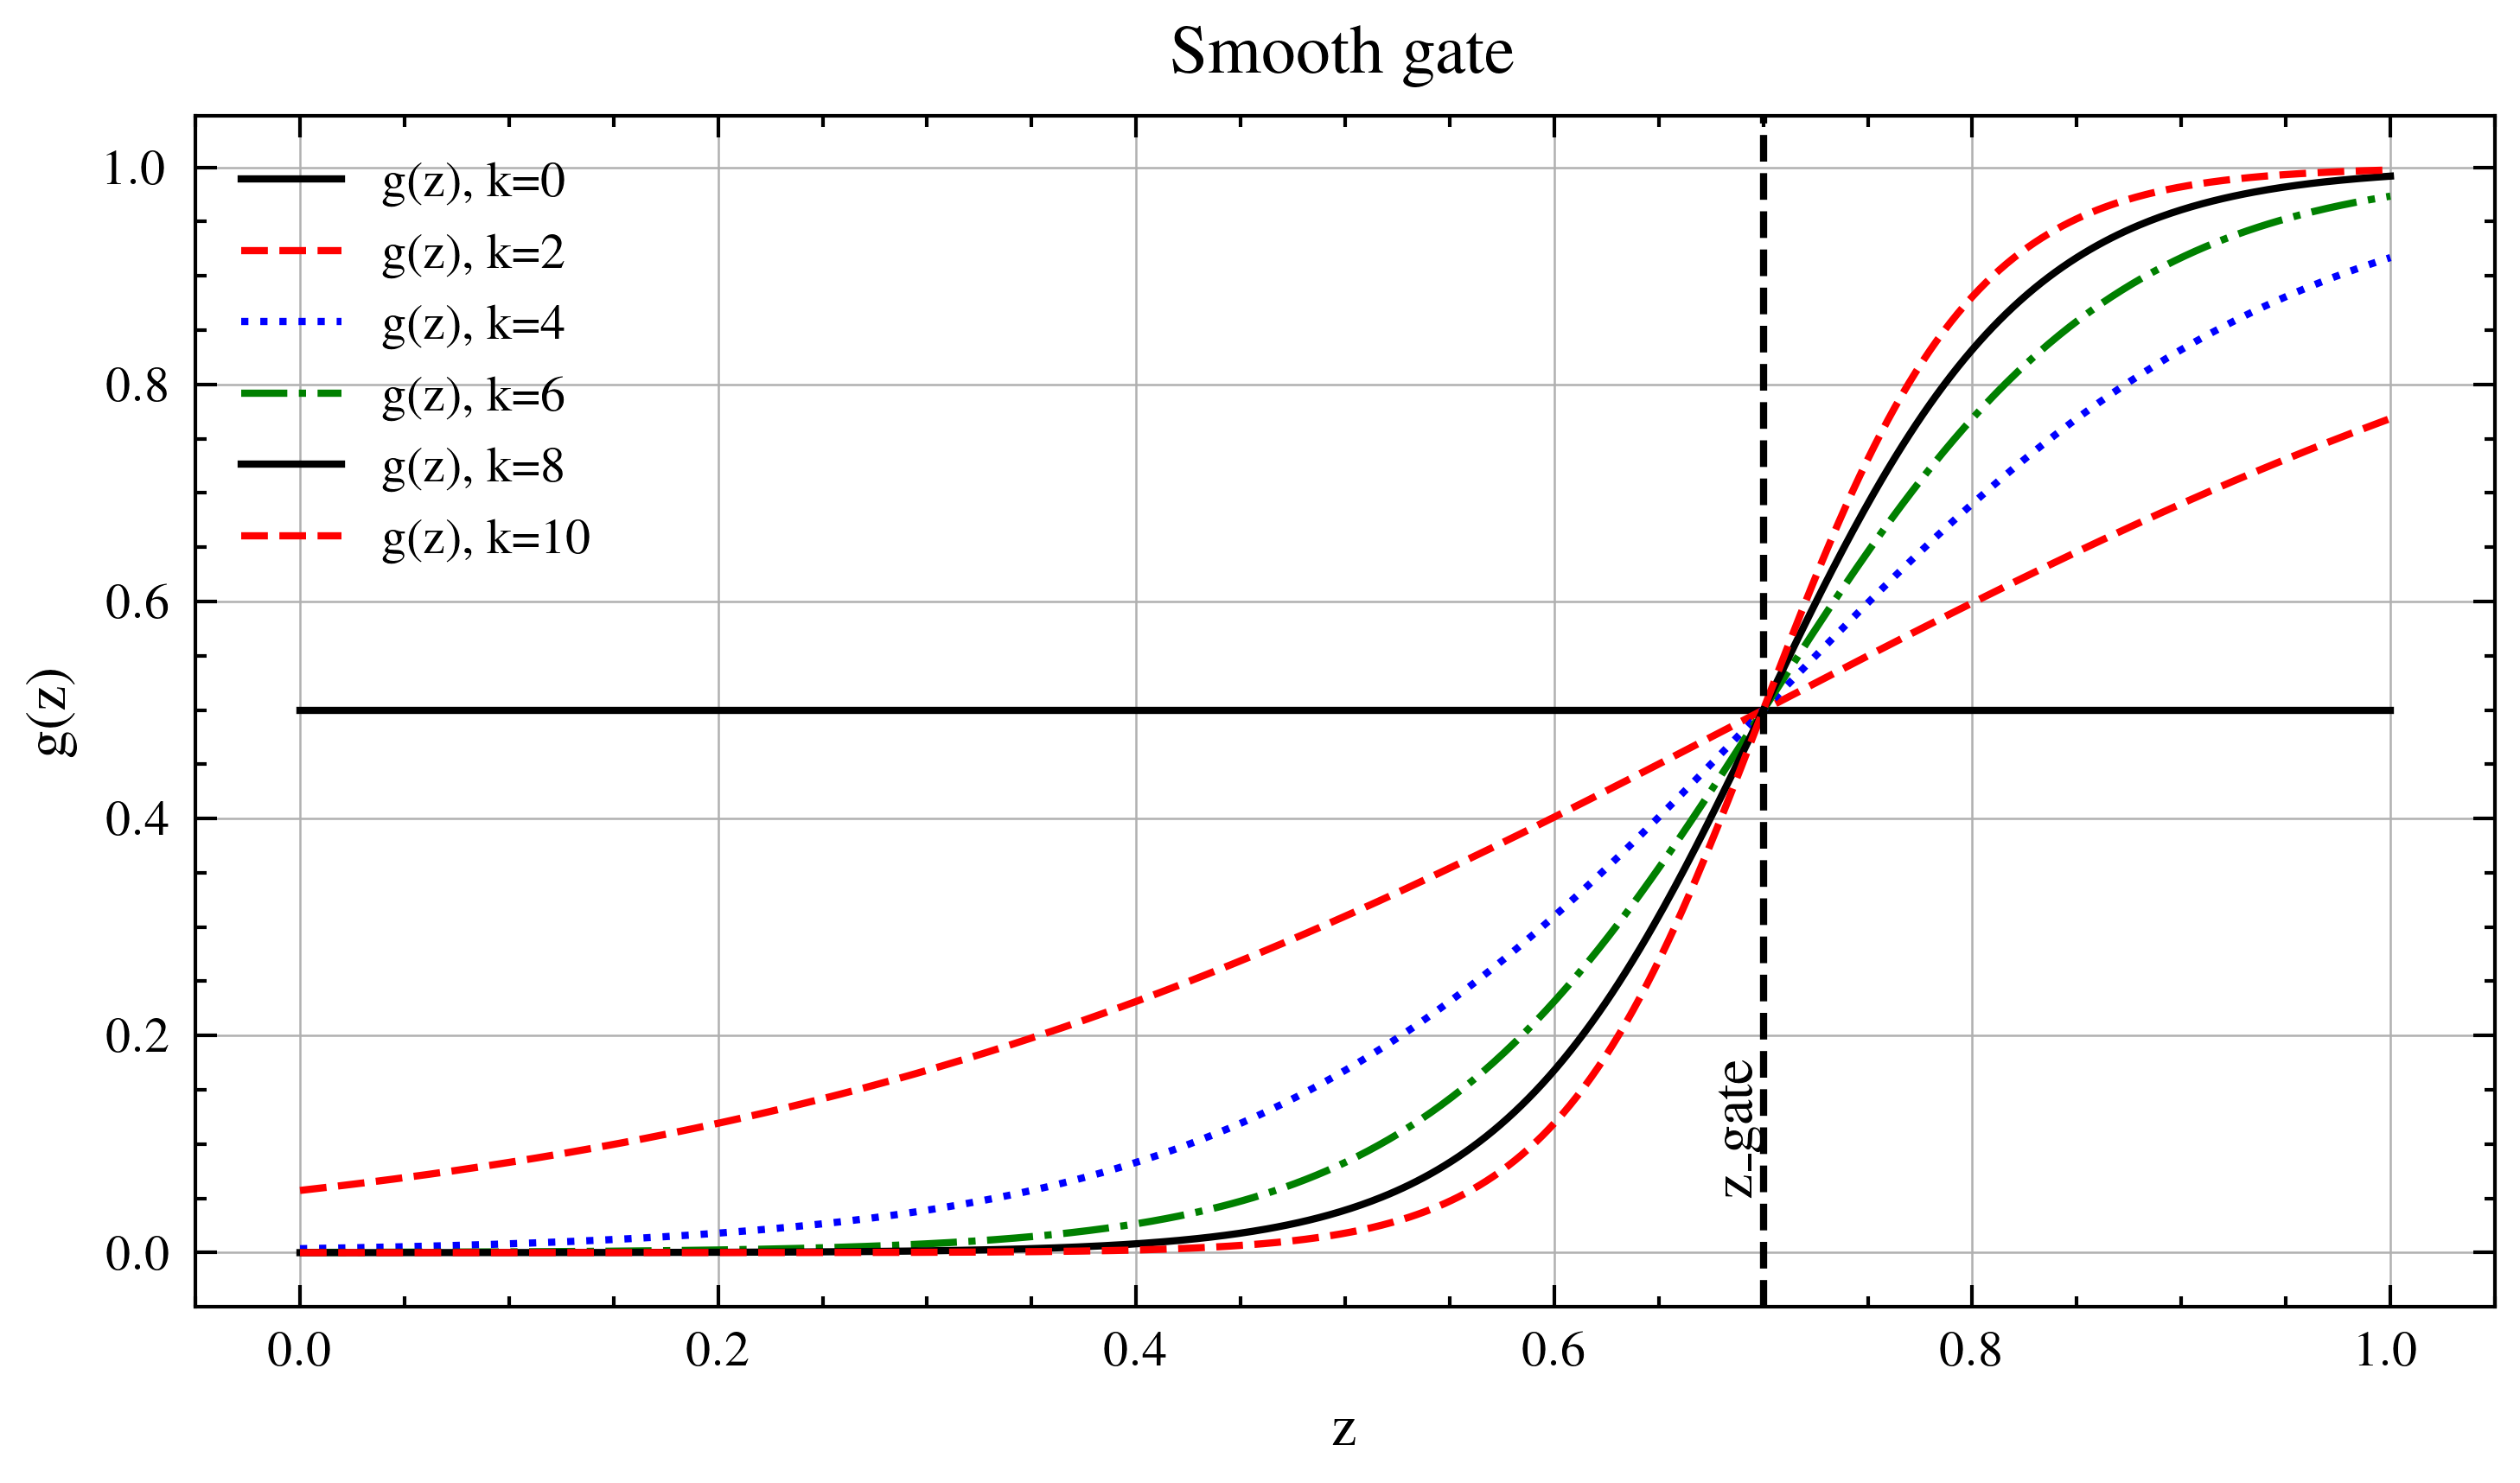

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- parameters ---
z_min, z_max = 0.0, 1.0
z_gate = 0.7          # gate height
k = range(0, 11, 2)               # sharpness (larger = sharper transition)

# --- gate function ---
def g(z, z_gate, k):
    return 0.5 * (1.0 + np.tanh(k * (z - z_gate)))

# --- data ---
z = np.linspace(z_min, z_max, 600)
gz = [g(z, z_gate, k) for k in k]

# --- plot ---
plt.figure(figsize=(5,3))
for i, gk in enumerate(gz):
    plt.plot(z, gk, label=f"g(z), k={k[i]:g}")
plt.axvline(z_gate, linestyle="--", linewidth=1.0)  # z_gate marker
plt.text(z_gate, 0.05, "z_gate", rotation=90, va="bottom", ha="right")

plt.xlabel("z")
plt.ylabel("g(z)")
plt.title("Smooth gate")
plt.grid(True, linewidth=0.3)
plt.legend()
plt.tight_layout()

# Optional: save for LaTeX
# plt.savefig("gate_curve.png", dpi=300)

plt.show()


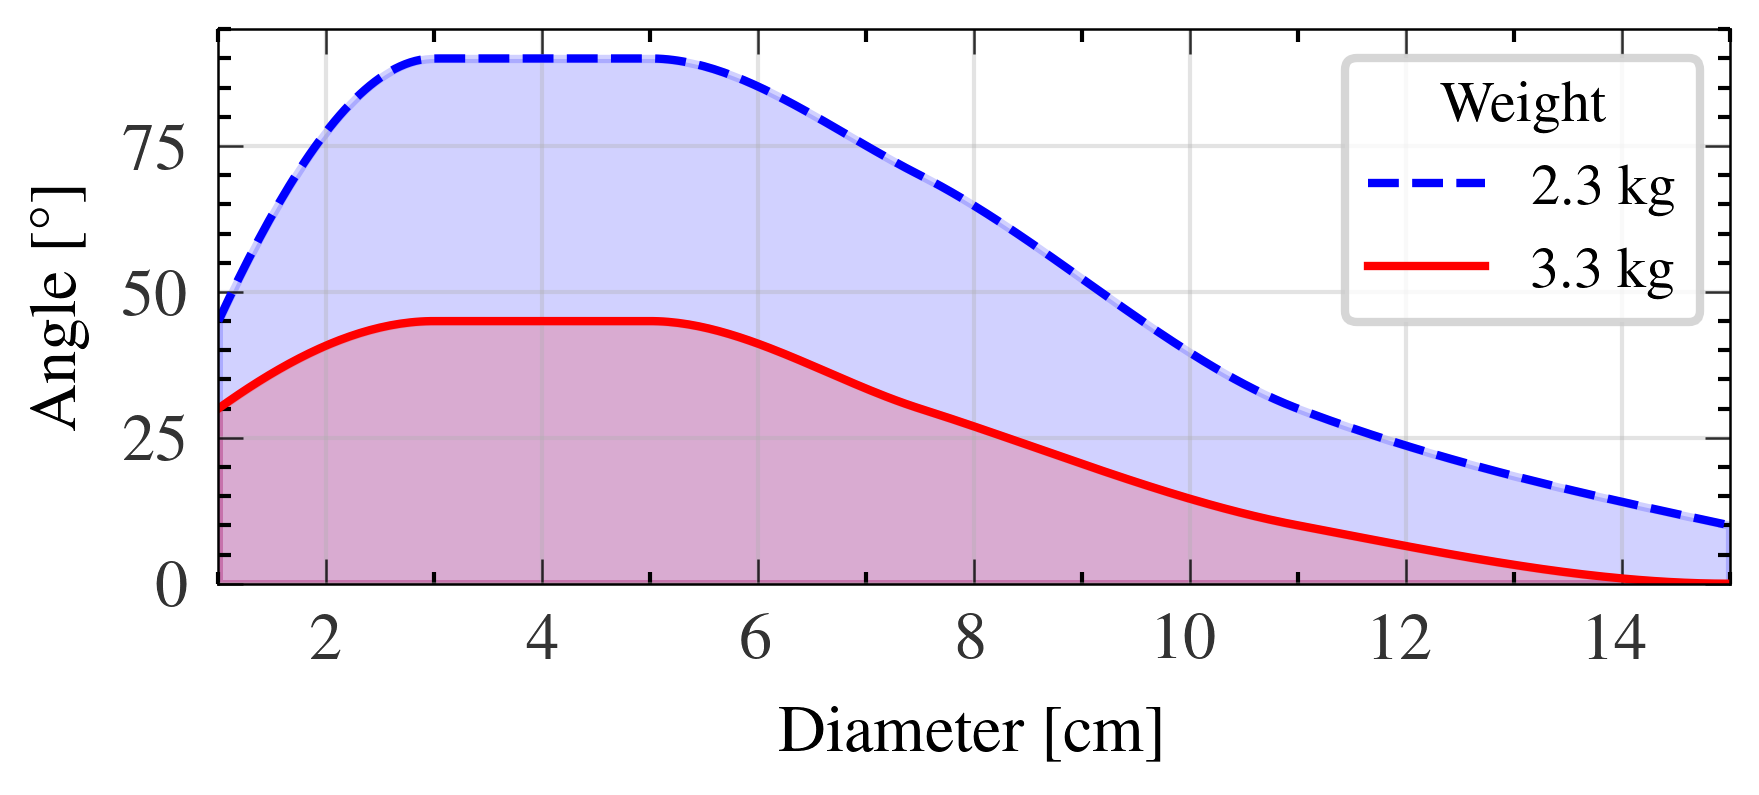

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator   # safer than cubic for endpoints
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# Raw data
radius_raw    = np.array([1.0, 3.0, 3.6, 4.0, 5.0, 7.5, 11.0, 15.0, 18.0])
kut_bez_raw   = np.array([45,  90, 90,  90,  90,  70,  30,  10,  0])
kut_teret_raw = np.array([30,  45, 45,  45,  45,  30,  10,  0, 0])

# Valid entries
valid_bez   = ~np.isnan(kut_bez_raw)
valid_teret = ~np.isnan(kut_teret_raw)

# Interpolators
f_bez   = PchipInterpolator(radius_raw[valid_bez],   kut_bez_raw[valid_bez])
f_teret = PchipInterpolator(radius_raw[valid_teret], kut_teret_raw[valid_teret])

# Fine grids
x_min, x_max = 1.0, 15.0
x_fine = np.linspace(x_min, x_max, 300)
x_fine_teret = x_fine[x_fine <= radius_raw[valid_teret].max()]  # respect data range

# Plot
fig, ax = plt.subplots(figsize=(3.25, 1.2), dpi=600)

ax.plot(x_fine,        f_bez(x_fine),        label='2.3 kg', color='C2', linestyle='--')
ax.fill_between(x_fine, f_bez(x_fine),                       color='C2', alpha=0.18)

ax.plot(x_fine_teret,  f_teret(x_fine_teret), label='3.3 kg', color='C1', linestyle='-')
ax.fill_between(x_fine_teret, f_teret(x_fine_teret),         color='C1',  alpha=0.18)

ax.set_xlim(x_min, x_max)
ax.set_ylim(0, 95)
ax.set_xlabel('Diameter [cm]')
ax.set_ylabel('Angle [°]')
ax.grid(True, alpha=0.35)

# Uniform ticks: 2 cm major, 1 cm minor
ax.xaxis.set_major_locator(MultipleLocator(2.0))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(colors=(0, 0, 0, 0.8), width=0.3)
for spine in ax.spines.values():
    spine.set_linewidth(0.3)
# Single legend
lgd = ax.legend(title='Weight', fontsize=7, frameon=True, loc='upper right')
lgd.get_title().set_fontsize(7)

plt.show()
out_path = "figures/angle_vs_diameter.pdf"
fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
plt.close(fig)
